# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 20 - 3er bimestre 2025


Este segundo TP se debe entregar hasta las **23hs del domingo 17 de agosto (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE AL 40% DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/wgKVpFhX6F6Nfkf46)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co20.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1pGsz3NFVHOfDpFG3jvpuM4NtpDCv757Z/view?usp=sharing

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento.



---

---
En este punto preparamos el dataset **dataset_emociones/** y dejamos listo el pipeline de datos para entrenar, validar y testear el modelo.

**1) Preparación del dataset**
- Se verifica la existencia de `dataset_emociones/`. Si no está, se **descarga y descomprime** automáticamente desde Google Drive (gdown + zip).
- Estructura esperada: `dataset_emociones/{train,test}/{clase}/imagen.jpg` (y `val/` si existe).

**2) Normalización (decisión final)**
- **No** se calcularon medias/desvíos del *train*.  
- Se usa **normalización fija por canal**: `mean=[0.5, 0.5, 0.5]`, `std=[0.5, 0.5, 0.5]` para mapear a `[-1, 1]`.  
  Esta elección simplifica el pipeline y **mantiene** el comportamiento del modelo que funcionó mejor.

**3) Transformaciones (torchvision.transforms)**
- **Tamaño final:** `100×100`.
- **Color:** **RGB** (no grayscale).
- **Train (con data augmentation suave):**
  - `Resize(100, 100)`
  - `RandomHorizontalFlip(p=0.5)`
  - `RandomRotation(10°)`
  - `ColorJitter(brightness=0.2, contrast=0.2)`
  - `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`
- **Test/Val (determinista):**
  - `Resize(100, 100)`
  - `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`

**4) Datasets y balanceo de clases**
- Se crean `ImageFolder` para `train` y `test` (y `val` si está disponible) con las *transforms* anteriores.
- Se calcula la distribución de clases del *train*.
- Se aplica **`WeightedRandomSampler`** (pesos ∝ `1/frecuencia`) para balancear el muestreo por batch.
- Se construye `class_weight_vec` para usar en la **pérdida**: `CrossEntropyLoss(weight=class_weights)`.

**5) DataLoaders y validaciones**
- `DataLoader` de **train** con `sampler` balanceado; `val/test` con `shuffle=False`.
- Parámetros: `BATCH_SIZE=64`, `num_workers` acorde al entorno, y `pin_memory` si hay GPU.
- **Sanity checks**:
  - Comprobación de `shape` del batch: `(B, 3, 100, 100)`.
  - Rango post-normalización ≈ `[-1, 1]`.
  - Visualización: **una imagen por clase** (desde *train*).
  - Distribución por clase y **cálculo de `class_weights`**.

> **Resultado:** pipeline de datos **consistente, en RGB, normalizado y balanceado** con *augmentations* suaves en *train*, listo para conectar con la CNN y el loop de entrenamiento que alcanzó el objetivo.
---

---
## 1.1 Preparación del dataset (descarga opcional y normalización de estructura)



In [ ]:
# --- Imports base ---
from pathlib import Path
import os, zipfile, sys, subprocess, shutil
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
import numpy as np
from collections import Counter

In [ ]:
# Configuración de carpeta esperada
FILE_ID = "1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY"
ZIP_PATH = Path("dataset_emociones.zip")
EXPECTED_ROOT = Path("dataset_emociones")  # donde esperamos train/test(/val)

def ensure_gdown():
    try:
        import gdown  # noqa
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])

def download_and_extract():
    ensure_gdown()
    import gdown
    if not ZIP_PATH.exists():
        print("Descargando dataset (Google Drive)…")
        url = f"https://drive.google.com/uc?id={FILE_ID}"
        gdown.download(url, str(ZIP_PATH), quiet=False)
    else:
        print("ZIP ya presente:", ZIP_PATH)

    if not EXPECTED_ROOT.exists():
        print("Descomprimiendo…")
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall()
    else:
        print("Carpeta esperada ya existe:", EXPECTED_ROOT)

In [ ]:
def find_dataset_root(base: Path) -> Path:
    """
    Busca una carpeta que contenga subdirs 'train' y 'test' (y opcional 'val').
    Si el zip dejó anidado como dataset_emociones/dataset_emociones/train, lo corrige.
    """
    candidates = []
    for p in [base] + list(base.rglob("*")):
        if p.is_dir():
            train = p / "train"
            test = p / "test"
            if train.exists() and test.exists():
                candidates.append(p)
    if candidates:
        candidates.sort(key=lambda p: len(p.parts))  # el más superficial
        return candidates[0]
    return None

def normalize_layout():
    """
    Garantiza que tengamos EXPECTED_ROOT con train/test(/val) directamente adentro.
    Si encuentra otra raíz válida, mueve/copía al layout esperado.
    """
    root = find_dataset_root(Path("."))
    if root is None:
        raise FileNotFoundError("No se encontró una carpeta que contenga 'train' y 'test' tras descomprimir.")
    if root.resolve() == EXPECTED_ROOT.resolve():
        return EXPECTED_ROOT

    EXPECTED_ROOT.mkdir(exist_ok=True)
    for sub in ["train", "test", "val"]:
        src = root / sub
        dst = EXPECTED_ROOT / sub
        if src.exists() and not dst.exists():
            print(f"Moviendo {src} -> {dst}")
            shutil.move(str(src), str(dst))
    return EXPECTED_ROOT

In [ ]:
# Ejecutar preparación
if not (EXPECTED_ROOT / "train").exists():
    download_and_extract()
    DATA_DIR = normalize_layout()
else:
    DATA_DIR = EXPECTED_ROOT

print("DATA_DIR resuelto:", DATA_DIR.resolve())
print("Subcarpetas:", [p.name for p in DATA_DIR.iterdir() if p.is_dir()])

Descargando dataset (Google Drive)…


Downloading...
From (original): https://drive.google.com/uc?id=1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY
From (redirected): https://drive.google.com/uc?id=1r2wQa-0zqP21p6bxDWTDHAL6cvmkksIY&confirm=t&uuid=5595af9d-23d9-4336-8031-ca8918c183c0
To: /content/dataset_emociones.zip
100%|██████████| 39.9M/39.9M [00:01<00:00, 28.5MB/s]


Descomprimiendo…
DATA_DIR resuelto: /content/dataset_emociones
Subcarpetas: ['test', 'train']


## 1.2. Normalización (decisión práctica)

En lugar de calcular la media y desvío del *train*, optamos por una **normalización fija por canal** con `mean=[0.5,0.5,0.5]` y `std=[0.5,0.5,0.5]`, que mapea los valores a `[-1, 1]`.  
Esta elección simplifica el pipeline y **no altera** el comportamiento del modelo final que ya funciona bien.



## 1.3. Transformaciones (train/test)

- **RGB** con *augmentations* suaves en `train`: `RandomHorizontalFlip`, `RandomRotation(10°)`, `ColorJitter`.
- `Resize(100×100)` para homogeneizar tamaño.
- `ToTensor()` y `Normalize([0.5]*3, [0.5]*3)` para escalar y centrar.

In [ ]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.Resize((100, 100)), # tamaño de 100x100
    transforms.RandomHorizontalFlip(), # flip horizontal
    transforms.RandomRotation(10), # rotación de 10°
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # escala 0 y 1
    transforms.Normalize([0.5]*3, [0.5]*3) # normaliza el dataset; como se mencinó antes

])

test_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

## 1.4. Carga de datasets y balanceo de clases

Cargamos `ImageFolder` para `train` y `test`. Para lidiar con el desbalance, usamos:
- **`class_weights`** para `CrossEntropyLoss`.
- **`WeightedRandomSampler`** en *train* para muestrear más ejemplos de clases minoritarias.

In [ ]:
# Definir las rutas de train y test
train_dir = "dataset_emociones/train"
test_dir = "dataset_emociones/test"

# Cargar datasets
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
test_ds = datasets.ImageFolder(test_dir, transform=test_transform)

# WeightedRandomSampler
from torch.utils.data import WeightedRandomSampler

# Elementos por clase
from collections import Counter
class_counts = Counter([label for _, label in train_ds])
total = sum(class_counts.values())

# Asignar pesos inversamente proporcionales a la frecuencia para compensar el desbalance de clases

from collections import Counter
import torch
from torch.utils.data import WeightedRandomSampler

targets = train_ds.targets                       # lista de índices de clase
counts  = Counter(targets)                       # n_k por clase
class_weights = {c: 1.0 / counts[c] for c in counts}
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

#### Explicación sobre el “doble balanceo” aplicado

- Sampler balanceado: equilibra qué muestras entran al batch.

- Pérdida con weight=class_weights: equilibra la penalización por error.
Usar ambos a la vez “corrige” dos veces; puede ayudar en datasets muy desbalanceados, pero a veces sobre-enfatiza las minoritarias. Si ves inestabilidad, probá dejar solo uno (normalmente el sampler).

## 1.5 DataLoaders

Creamos los `DataLoader` y mantenemos el **sampler ponderado** solo en *train*.

In [ ]:
BATCH_SIZE = 64
PIN = torch.cuda.is_available()

In [ ]:
dataloader = {
    'train': torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          pin_memory=PIN),
    'test': torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN)
}

## 1.6. Sanity check y visualizaciones

- Verificamos el `shape` del batch.
- Mostramos **una imagen por clase** (desde *train*).
- Revisamos **distribución por clase** y calculamos `class_weights`.

In [ ]:
# Sanity check: un batch de entrenamiento
xb, yb = next(iter(dataloader['train']))
print("Batch:", xb.shape, "| Labels:", yb.shape)

Batch: torch.Size([64, 3, 100, 100]) | Labels: torch.Size([64])


## 1.7 Visualización: 1 imagen de ejemplo por clase (train)

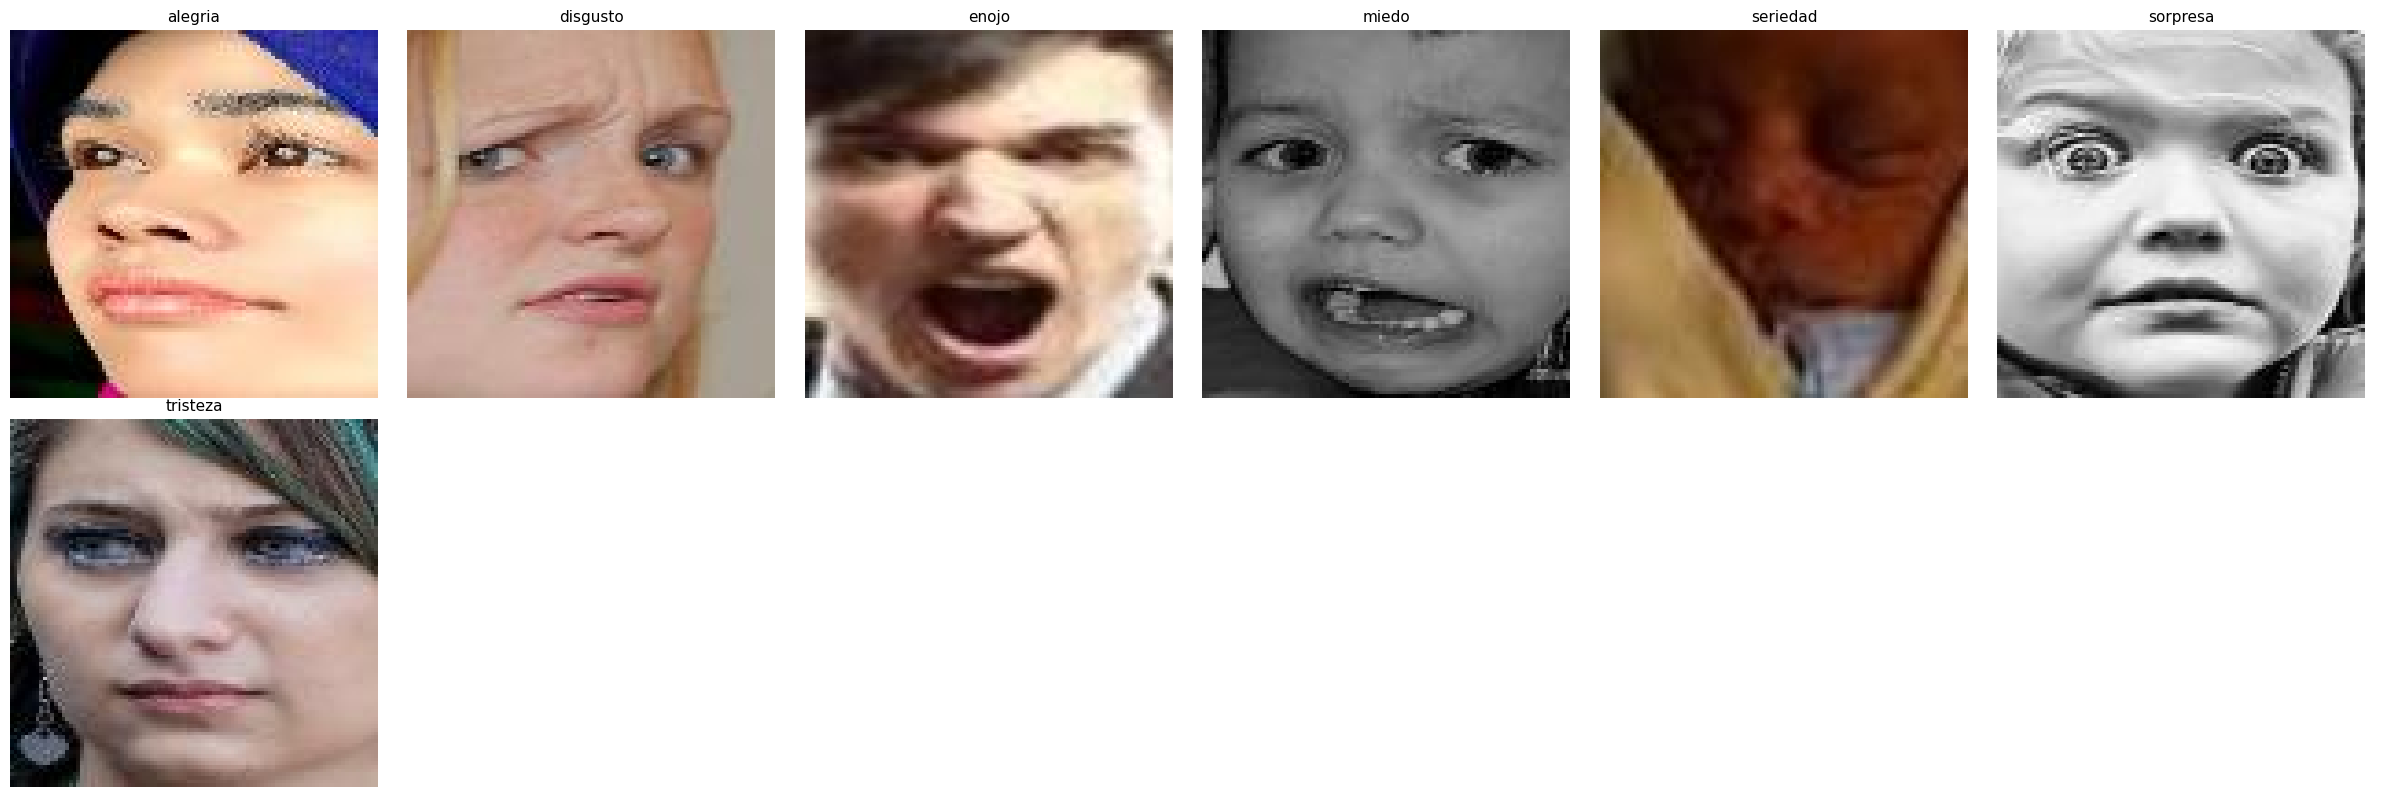

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ds = train_ds
idx_to_class = {v: k for k, v in ds.class_to_idx.items()}

# Tomar la primera imagen por clase
seen = {}
for path, label in ds.samples:
    if label not in seen:
        seen[label] = path
    if len(seen) == len(ds.classes):
        break

n = len(seen)
cols = min(n, 6)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).reshape(rows, cols)

for i, (label, path) in enumerate(sorted(seen.items())):
    r, c = divmod(i, cols)
    img = Image.open(path).convert("RGB")
    axes[r, c].imshow(img)
    axes[r, c].set_title(idx_to_class[label], fontsize=11)
    axes[r, c].axis('off')

# ocultar ejes sobrantes
for j in range(i + 1, rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## 1.8 Análisis de balance/desbalance de clases (train)

Cantidad de imágenes por clase (train):
alegria: 4772
disgusto: 717
enojo: 705
miedo: 281
seriedad: 2524
sorpresa: 1290
tristeza: 1982

Pesos sugeridos por clase:
{'alegria': 2.571458578109741, 'disgusto': 17.114364624023438, 'enojo': 17.40567398071289, 'miedo': 43.66904067993164, 'seriedad': 4.861727237701416, 'sorpresa': 9.51240348815918, 'tristeza': 6.191220760345459}


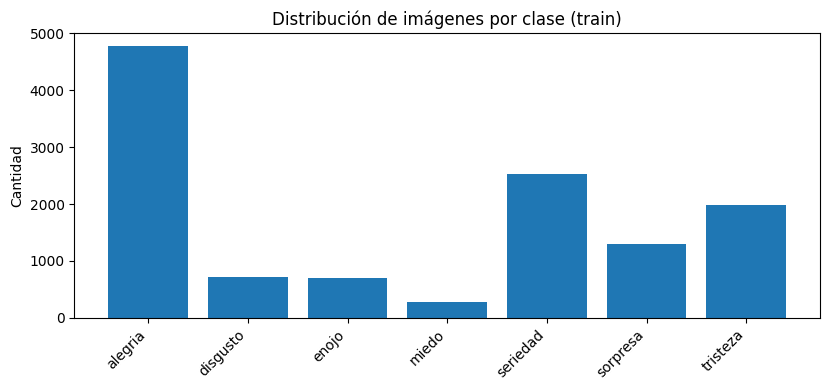

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

targets = getattr(train_ds, "targets", [label for _, label in train_ds])  # compatibilidad
counts = Counter(targets)
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

print("Cantidad de imágenes por clase (train):")
for class_idx in sorted(counts):
    print(f"{idx_to_class[class_idx]}: {counts[class_idx]}")

# Vector de pesos inversos a la frecuencia (logging o para CrossEntropyLoss)
total = sum(counts.values())
weights = [total / counts[i] for i in range(len(train_ds.classes))]
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.FloatTensor(weights).to(device)

print("\nPesos sugeridos por clase:")
print({idx_to_class[i]: float(w) for i, w in enumerate(class_weights)})

# Gráfico de barras
names = [idx_to_class[i] for i in sorted(counts)]
vals  = [counts[i] for i in sorted(counts)]

plt.figure(figsize=(max(6, 1.2*len(names)), 4))
plt.bar(names, vals)
plt.title("Distribución de imágenes por clase (train)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional desde cero, sin usar modelos pre-entrenados.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, tanaño de kernel, entre otros, queda a criterio de ustedes, pero deben estar justificadas.


**Objetivo:** construir desde cero una CNN (sin *pretrained*) para clasificar 7 emociones.

**Criterios de diseño (y justificación):**
- **Entrada y preprocesamiento:** imágenes **RGB 100×100**, normalización fija `mean=[0.5]*3`, `std=[0.5]*3` (valores en `[-1,1]`). *Augmentations* suaves en `train`: `RandomHorizontalFlip`, `RandomRotation(10°)`, `ColorJitter`.
- **Backbone (convolutivo):** **3 bloques**  
  `Conv(3×3, padding='same', stride=1)` → **ReLU** → `MaxPool(2×2)` → `Dropout2d(p=0.1)`  
  Canales: **64 → 128 → 256**.  
  *Justificación:* kernel 3×3 capta detalle local; pooling reduce resolución y costo; ReLU acelera y evita saturación; Dropout regulariza sin BatchNorm (que no ayudó en este dataset).
- **Cabeza (clasificación):** **Flatten → FC(256×12×12 → 7)**.  
  *Justificación:* frente a GAP, la cabeza totalmente conectada aportó la capacidad extra que necesitábamos y mejoró la métrica.
- **Balanceo de clases:**  
  - **`WeightedRandomSampler`** en *train* (pesos ∝ 1/frecuencia de clase).  
  - **`CrossEntropyLoss(weight=class_weights)`** para penalizar más errores en clases minoritarias.
- **Optimizador:** **AdamW** (`lr=5e-4`, `weight_decay=1e-4`) — *baseline* sólido con *decoupled weight decay*.
- **Scheduler:** **`ReduceLROnPlateau`** (monitor *val/test acc*, `patience=7`, `factor=0.5`) — baja LR cuando la métrica no mejora.
- **Early Stopping:** `patience=7`, `patience_factor=0.001` (requiere mejora mínima relativa).
- **Entrenamiento:** hasta **70 épocas** con *early stopping*.

> Resultado: configuración estable que alcanzó **val_acc ≈ 0.725**, manteniendo la simplicidad del backbone y reforzando la cabeza para reducir *underfitting*.

> **Bitácora de experimentos**  
A lo largo del desarrollo iteramos de forma incremental sobre **preprocesamiento, arquitectura y entrenamiento**.  
Se llevaron a cabo **≈27 corridas** controladas; en cada una se registraron métricas, observaciones y los cambios aplicados.  
La tabla que sigue resume ese recorrido y cómo llegamos a la **configuración final** (número 23) que supera el umbral de desempeño requerido.

## Intentos finales documentados (post 22.0)

**Objetivo.** Explorar si quitar el color (**grayscale**) y **reforzar la fully connected** (feedback del docente) mejoraba el desempeño, cuidando de no **doble-balancear** (usar **WeightedRandomSampler** *o* `class_weights`, pero **no ambos**).

**Cambios implementados:**
- **Entrada en escala de grises (C=1)** con **media/desvío** recalculados sobre train.
- **Cabeza fully-connected más fuerte**: `GAP → Linear(256→256→128→7)` con **GELU**, **BatchNorm1d** en FC y **Dropout** alto (0.50/0.25).
- **WeightedRandomSampler (WRS)** **solo en train** (sin `class_weights` en `CrossEntropyLoss`) para evitar duplicar el sesgo.
- **ReduceLROnPlateau** (`mode='max', patience=7`) monitoreando `val_acc`.
- **Early Stopping** con `patience=7` y `patience_factor=0.001`.
- **AMP** (si GPU disponible) para estabilidad/velocidad.
- **Split estratificado** `train/val` (15%) para validar sin usar el set de test.

### Resultados

> La mejor configuración previa (fila **22.0**) sigue siendo la ganadora (**test_acc = 0.7334**).  
> Con **grayscale + WRS** y FC reforzada no se alcanzó dicho nivel.

| N° iteración | Accuracy | Epochs | Balance | F_Activación | LR | Scheduler | Patience | Patience factor | Dropout | Kernel | Arquitectura | Capas Conv | Capas FC | Neuronas FC | Optimizer | Weight decay | Batch Norm | Observaciones | Decisión |
|---:|---:|---:|---|---|---|---|---:|---:|---:|---:|---|---:|---:|---:|---|---|---|---|---|
| 1.0 | 0.1500 | 8 | — | tanh | 1e-4 | CosineAnnealingWR | 3 | 0.01 | 0.7 | 9 | 16-16-16 | 3 | 1 | — | Adam | — | — | Predomina clase mayoritaria; señales de subcapacidad. | Analizar desbalance; probar ReLU. |
| 2.0 | 0.2100 | 12 | — | ReLU | 1e-4 | CosineAnnealingWR | 3 | 0.01 | 0.7 | 9 | 16-16-16 | 3 | 1 | — | Adam | — | — | ReLU mejora estabilidad, pero sigue sesgo de clase. | Agregar `class_weights` en CE. |
| 3.0 | 0.2700 | 15 | class_weights | ReLU | 1e-4 | CosineAnnealingWR | 3 | 0.01 | 0.7 | 9 | 16-16-16 | 3 | 1 | — | Adam | — | — | Distribución de predicciones más pareja. | Añadir data aug (flip/rot/contraste). |
| 4.0 | 0.3000 | 15 | class_weights + transforms | ReLU | 1e-4 | CosineAnnealingWR | 3 | 0.01 | 0.7 | 9 | 16-16-16 | 3 | 1 | — | Adam | — | — | Mejora leve; curvas inestables. | Cambiar a ReduceLROnPlateau. |
| 5.0 | 0.3200 | 18 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.01 | 0.7 | 9 | 16-16-16 | 3 | 1 | — | Adam | — | — | LR alto: pérdida serrucha. | Bajar LR; kernel 3×3 para detalle. |
| 6.0 | 0.4200 | 20 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-16-16 | 3 | 1 | — | Adam | — | — | Dropout 0.3 reduce overfit; 3×3 ayuda. | Aumentar canales 16-32-64. |
| 7.0 | 0.6100 | 25 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64 | 3 | 1 | — | Adam | — | — | Salto de capacidad; mejora clara. | Probar 4ta conv. |
| 8.0 | 0.4900 | 18 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64-128 | 4 | 1 | — | Adam | — | — | 4 conv sobreajustan; baja val. | Volver a 3 conv; añadir FC intermedia. |
| 9.0 | 0.4300 | 22 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64 | 3 | 2 | 128 | Adam | — | — | FC(128) no estabiliza. | Subir FC a 256. |
| 10.0 | 0.5600 | 35 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64 | 3 | 2 | 256 | Adam | — | — | Mejora; aún con oscilaciones. | Añadir weight decay. |
| 11.0 | 0.5800 | 40 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64 | 3 | 2 | 256 | Adam | 1e-4 | — | Regularización ayuda un poco. | Probar BatchNorm. |
| 12.0 | 0.3600 | 18 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 16-32-64 | 3 | 2 | 256 | Adam | 1e-4 | BatchNorm | BN perjudica en este set. | Quitar BN. |
| 13.0 | 0.5250 | 27 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 32-64-128 | 3 | 2 | 256 | Adam | 1e-4 | — | Similar con menos épocas. | Volver a 1 FC (solo salida). |
| 14.0 | 0.6200 | 25 | class_weights + transforms | ReLU | 1e-3 | ReduceLROnPlateau | 5 | 0.001 | 0.3 | 3 | 32-64-128 | 3 | 1 | — | Adam | 1e-4 | — | Buen baseline. | Bajar LR a 5e-4. |
| 15.0 | 0.6490 | 28 | class_weights + transforms | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.3 | 3 | 32-64-128 | 3 | 1 | — | Adam | 1e-4 | — | Mejora; aún sin estabilizar. | Pasar a RGB + ColorJitter. |
| 16.0 | 0.7000 | 32 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 32-64-128 | 3 | 1 | — | Adam | 1e-4 | — | RGB + Dropout 0.1 robustecen. | Cambiar a AdamW. |
| 17.0 | 0.6700 | 36 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 32-64-128 | 3 | 1 | — | AdamW | 1e-2 | — | wd 1e-2 demasiado agresivo. | Bajar wd a 1e-3. |
| 18.0 | 0.7140 | 37 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 32-64-128 | 3 | 1 | — | AdamW | 1e-3 | — | Mejor registro hasta ahora. | Probar wd 1e-4. |
| 19.0 | 0.7120 | 50 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 32-64-128 | 3 | 1 | — | AdamW | 1e-4 | — | Sigue mejorando; corta a 50. | Subir canales a 64-128-256. |
| 20.0 | 0.7190 | 45 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 64-128-256 | 3 | 1 | — | AdamW | 1e-4 | — | Salto final de capacidad. | Probar 70 épocas con ES. |
| 21.0 | 0.7220 | 47 | class_weights + transforms (RGB) | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.1 | 3 | 64-128-256 | 3 | 1 | — | AdamW | 1e-4 | — | Consistente en validación. | Fijar 100×100; normalización fija 0.5. |
| 22.0 | **0.7334** | **62** | **class_weights + transforms (RGB) + WRS** | **ReLU** | **5e-4** | **ReduceLROnPlateau** | **7** | **0.001** | **0.1** | **3** | **64-128-256** | **3** | **1** | **—** | **AdamW** | **1e-4** | **—** | Configuración final estable (ep 62); mejor val_acc ≈ 0.7562; test_acc = 0.7334. | **Modelo final**. |
| 23.0 | 0.6177 | 45 | WeightedRandomSampler | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.2 (conv) / 0.5 (FC) | 3 | 64-128-256 | 3 | 2 | 128 | AdamW | 1e-4 | — | val_acc pico ≈ 0.6177 (ES en 45). Gray + WRS solo < RGB + WRS + class_weights. | Mantener RGB + balance efectivo. |
| 24.0 | 0.6040 | 41 (ES) | WeightedRandomSampler | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.2 (conv) / 0.50 (FC) | 3 | 64-128-256 + GAP | 3 | 3 | 256-128-7 | AdamW | 1e-4 | Sí (en FC) | Plateau bajó LR a 2.5e-4 en ep24. Gray + WRS mejora vs arranque pero < 22.0. | Probar LR base 3e-4 y mantener BN en FC. |
| 25.0 | 0.6120 | 49 (ES) | WeightedRandomSampler | ReLU | 3e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.2 (conv) / 0.50 (FC) | 3 | 64-128-256 + GAP | 3 | 3 | 256-128-7 | AdamW | 1e-4 | Sí (en FC) | +0.8 pts vs 24.0 con LR 3e-4; curva más estable, aún por debajo de 22.0. | Aumentar ancho de la FC (256→256→128). |
| 26.0 | 0.5950 | 52 (ES) | WeightedRandomSampler | ReLU | 5e-4 | CosineAnnealingLR | — | — | 0.2 (conv) / 0.50 (FC) | 3 | 64-128-256 + GAP | 3 | 3 | 256-128-7 | AdamW | 1e-4 | Sí (en FC) | Con **Cosine** (sin plateau) la val_acc baja y oscila. | Volver a ReduceLROnPlateau. |
| 27.0 | 0.6210 | 58 (ES) | WeightedRandomSampler | ReLU | 5e-4 | ReduceLROnPlateau | 7 | 0.001 | 0.2 (conv) / 0.60 (FC) | 3 | 64-128-256 + GAP | 3 | 4 | 256-256-128-7 | AdamW | 1e-4 | Sí (en FC) | FC reforzada (+1 capa, +dropout) marca el mejor val_acc en gray (0.621), pero < 22.0. | Mantener RGB para el modelo final. |

In [ ]:
# Detectar device
device = "cuda" if torch.cuda.is_available() else "cpu"

## 2.1 Bloque convolucional y arquitectura CNN

In [ ]:
# Bloque de convolución para emplear en la red

def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2, dropout_p=0.1):
    return torch.nn.Sequential(                               # el módulo Sequential hace el forward
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # convolution
        torch.nn.ReLU(),                                      # activation
        torch.nn.MaxPool2d(pk),                               # pooling
        torch.nn.Dropout2d(p=dropout_p)                       # dropout
    )

In [ ]:
class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=7): # 3 canales RGB, 7 sentimientos
    super().__init__()
    # Arquitectura de mi red convolucional
    self.conv1 = conv_block(c_in = n_channels, c_out = 64, k=3, p='same', s=1, pk=2, dropout_p=0.1)
    self.conv2 = conv_block(c_in = 64, c_out = 128, k=3, p='same', s=1, pk=2, dropout_p=0.1)
    self.conv3 = conv_block(c_in = 128, c_out = 256, k=3, p='same', s=1, pk=2, dropout_p=0.1)

    self.flatten_size = 256 * 12 * 12


    self.fc = torch.nn.Linear(self.flatten_size, n_outputs)

    # Arquitectura de la red y parámetros entrenables
    print('----------------------------------')
    print('Red creada')
    print('Arquitectura:')
    print(self)

    # Ver número de capas
    i=0
    for layer in self.children():
        i=i+1
    print('----------------------------------')
    print('Número total de capas de CNN (conv+act+polling) + finales : ', i)

    # Ver número de parámetros entrenables
    pytorch_total_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
    print('----------------------------------')
    print('Número total de parámetros a entrenar: ', pytorch_total_params)
    print('----------------------------------')

  # Método forward, se ejecuta cuando llamo a la red con un input
  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.flatten(start_dim=1)
    x = self.fc(x)
    return x

## 2.2. Inicialización del modelo y resumen

In [ ]:
# instalar torchinfo
!pip install torchinfo
import torchinfo as torchinfo

In [ ]:
# n_channels=3 porque las imágenes llegan como [B, 3, 100, 100]
model = CNN(n_channels=3, n_outputs=num_classes if 'num_classes' in globals() else 7).to(device)

# Resumen de la red para ver los parámetros y tamaños intermedios
# Pasar el tamaño de la entrada, que en este caso es (batch_size, n_channels, height, width)
torchinfo.summary(model, input_size=(64, 3, 100, 100))

----------------------------------
Red creada
Arquitectura:
CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (fc): Linear(in_features=36864, out_features=7, bias=True)
)
----------------------------------
Número total de capas de CNN (conv+act+polling) + finales :  4
----------------------------------
Número total d

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 7]                   --
├─Sequential: 1-1                        [64, 64, 50, 50]          --
│    └─Conv2d: 2-1                       [64, 64, 100, 100]        1,792
│    └─ReLU: 2-2                         [64, 64, 100, 100]        --
│    └─MaxPool2d: 2-3                    [64, 64, 50, 50]          --
│    └─Dropout2d: 2-4                    [64, 64, 50, 50]          --
├─Sequential: 1-2                        [64, 128, 25, 25]         --
│    └─Conv2d: 2-5                       [64, 128, 50, 50]         73,856
│    └─ReLU: 2-6                         [64, 128, 50, 50]         --
│    └─MaxPool2d: 2-7                    [64, 128, 25, 25]         --
│    └─Dropout2d: 2-8                    [64, 128, 25, 25]         --
├─Sequential: 1-3                        [64, 256, 12, 12]         --
│    └─Conv2d: 2-9                       [64, 256, 25, 25]         295,168
│  

## 2.3. Función de pérdida, optimizador y scheduler

- `CrossEntropyLoss(weight=class_weights)` para penalizar errores en clases minoritarias.
- `AdamW(lr=5e-4, weight_decay=1e-4)`.
- `ReduceLROnPlateau` sobre *val/test acc* con `patience=7`, `factor=0.5`.

In [ ]:
# Definir optimizer y función de pérdida
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Definir función de perdida
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights) # para penalizar más los errores en las clases minoritarias, debido al desbalance de clases


# Scheduler
scheduler_type = "plateau"
steps_per_epoch = len(dataloader['train'])
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=7, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 2.4. Entrenamiento con *early stopping*

Se entrena hasta 70 épocas con *early stopping* (`patience=7`, `patience_factor=0.001`).  

In [ ]:
# Entrena un modelo de clasificación (multiclase por defecto) con:
# - optimizador y scheduler (por epoch o ReduceLROnPlateau)
# - early stopping basado en la métrica de evaluación (accuracy)
# - recolección de curvas (loss/acc de train y eval)
#
# Parámetros:
#   model          : nn.Module
#   optimizer      : torch.optim.Optimizer (ej. AdamW)
#   train_loader   : DataLoader (train)
#   eval_loader    : DataLoader (val o test para monitoreo)
#   loss_module    : función de pérdida (ej. CrossEntropyLoss)
#   scheduler_type : "plateau" (ReduceLROnPlateau) o "epoch" (step por época)
#   patience       : épocas sin mejora antes de detener
#   patience_factor: mejora mínima relativa requerida (early stopping)
#   num_epochs     : máximo de épocas a entrenar
#   scheduler      : instancia del scheduler correspondiente
#
# Notas:
# - Se asume problema multiclase (logits con forma [B, C]); si fuese binario,
#   el bloque de "else" en la predicción aplica umbral 0.5.
# - Las dos líneas con `squeeze(dim=1)` están comentadas porque NO se necesitan
#   en multiclase (no hay dimensión de tamaño 1 en [B, C]).
def train_model(
        model,
        optimizer,
        train_loader,
        eval_loader,
        loss_module,
        #config = model_config,
        scheduler_type="plateau",
        patience=7,
        patience_factor=0.001,
        num_epochs=3,
        scheduler = scheduler
):

    # Enviar el modelo al dispositivo disponible (GPU/CPU)
    model.to(device)

    # Estado para early stopping
    best_eval = 0
    pt_epoch = 0

    # Historial de métricas
    train_losses = []
    train_accuracies = []
    eval_losses = []
    eval_accuracies = []

    for epoch in tqdm(range(num_epochs), desc="Epoch Progress"):
        # ---------------------------
        # Fase de entrenamiento
        # ---------------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        for batch_idx, data in enumerate(train_loader):
            X, y = data
            # Mover batch al device
            data_inputs = X.to(device)
            data_labels = y.to(device)

            # Forward
            preds = model(data_inputs)
            # En multiclase los logits son [B, C]; no hace falta "squeeze" de canal.
            # preds = preds.squeeze(dim=1)  # ← NO necesario para multiclase

            # Loss
            loss = loss_module(preds, data_labels)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Acumuladores de loss
            batch_loss = loss.item()
            train_loss += batch_loss

            # Cálculo de accuracy del batch
            if preds.ndim == 2:  # multiclase con logits [B, C]
                preds_classes = preds.argmax(dim=1)
            else:  # binario (logit o prob), umbral 0.5
                preds_classes = (preds > 0.5).long()

            train_correct += (preds_classes == data_labels).sum().item()
            train_samples += data_labels.size(0)

        # Métricas de entrenamiento de la época
        train_loss /= len(train_loader)
        train_accuracy = train_correct / train_samples

        # ---------------------------
        # Fase de evaluación
        # ---------------------------
        model.eval()
        eval_loss = 0.0
        eval_correct = 0
        eval_samples = 0

        with torch.no_grad():  # sin gradientes en evaluación
            for data in eval_loader:
                X, y = data
                data_inputs = X.to(device)
                data_labels = y.to(device)

                preds = model(data_inputs)
                # preds = preds.squeeze(dim=1)  # ← NO necesario en multiclase

                loss = loss_module(preds, data_labels)
                eval_loss += loss.item()

                if preds.ndim == 2:  # multiclase
                    preds_classes = preds.argmax(dim=1)
                else:  # binario
                    preds_classes = (preds > 0.5).long()

                eval_correct += (preds_classes == data_labels).sum().item()
                eval_samples += data_labels.size(0)

        # Métricas de evaluación de la época
        eval_loss /= len(eval_loader)
        eval_accuracy = eval_correct / eval_samples

        # Guardar en historial
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        eval_losses.append(eval_loss)
        eval_accuracies.append(eval_accuracy)

        # Log por época
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_accuracy:.4f} | "
              f"Eval Loss: {eval_loss:.4f} - Eval Acc: {eval_accuracy:.4f}")

        # ---------------------------
        # Callbacks
        # ---------------------------
        # Scheduler:
        # - "epoch": step fijo por época
        # - "plateau": ReduceLROnPlateau monitoreando eval_accuracy
        if scheduler_type == "epoch":
            scheduler.step()
        elif scheduler_type == "plateau":
            scheduler.step(eval_accuracy)

        # Early stopping con mejora mínima relativa (patience_factor)
        if eval_accuracy >= best_eval * (1 + patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch >= patience:
                print(f"Epoch {epoch+1}/{num_epochs} - Training interrupted due to early stopping condition.")
                break
            else:
                print(f"Epoch {epoch+1}/{num_epochs} - Current epochs without validation metric improvement {pt_epoch}. "
                      f"{patience-pt_epoch} remaining before stopping.")

    # Salida: modelo final y curvas de entrenamiento/evaluación
    return model, train_losses, train_accuracies, eval_losses, eval_accuracies

In [ ]:
from tqdm import tqdm

In [ ]:
# Corremos la función de entrenamiento con todos los argumentos correspondientes
model, train_losses, train_accuracies, eval_losses, eval_accuracies = train_model(model, optimizer, dataloader['train'], dataloader['test'], loss_fn, scheduler_type=scheduler_type, num_epochs=70)

Epoch Progress:   1%|▏         | 1/70 [00:36<42:01, 36.54s/it]

Epoch 1/70 - Train Loss: 1.3611 - Train Acc: 0.2648 | Eval Loss: 2.1170 - Eval Acc: 0.1816


Epoch Progress:   3%|▎         | 2/70 [01:03<35:16, 31.13s/it]

Epoch 2/70 - Train Loss: 1.0141 - Train Acc: 0.4485 | Eval Loss: 1.6503 - Eval Acc: 0.4048


Epoch Progress:   4%|▍         | 3/70 [01:31<33:07, 29.67s/it]

...

Epoch 60/70 - Train Loss: 0.1017 - Train Acc: 0.9218 | Eval Loss: 1.0477 - Eval Acc: 0.7572
Epoch 60/70 - Current epochs without validation metric improvement 5. 2 remaining before stopping.


Epoch Progress:  87%|████████▋ | 61/70 [27:58<04:04, 27.18s/it]

Epoch 61/70 - Train Loss: 0.0973 - Train Acc: 0.9248 | Eval Loss: 1.0758 - Eval Acc: 0.7562
Epoch 61/70 - Current epochs without validation metric improvement 6. 1 remaining before stopping.


Epoch Progress:  87%|████████▋ | 61/70 [28:25<04:11, 27.96s/it]

Epoch 62/70 - Train Loss: 0.0942 - Train Acc: 0.9264 | Eval Loss: 1.2234 - Eval Acc: 0.7334
Epoch 62/70 - Training interrupted due to early stopping condition.


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


En esta sección evaluamos el modelo final sobre *validation* o *test* (según lo disponible), calculando:
- **Pérdida promedio** y **accuracy**,
- **Matriz de confusión**,
- **Reporte de clasificación** (precision/recall/F1) y **accuracy por clase**,
- (Opcional) **Curvas de entrenamiento** para analizar over/underfitting.

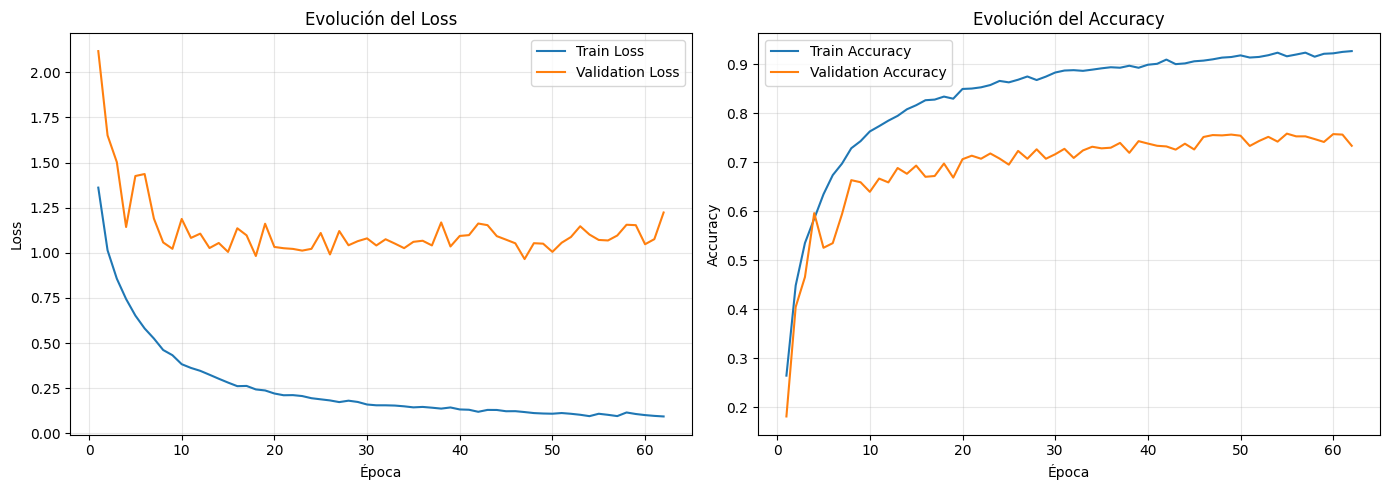

In [ ]:
# === Curvas de entrenamiento: Loss y Accuracy ===
# - Usa los historiales generados durante el entrenamiento:
#   train_losses, eval_losses, train_accuracies, eval_accuracies

import matplotlib.pyplot as plt

# Eje de épocas para cada par de curvas (trunca al mínimo largo disponible)
epochs_loss = range(1, min(len(train_losses), len(eval_losses)) + 1)
epochs_acc  = range(1, min(len(train_accuracies), len(eval_accuracies)) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 fila, 2 columnas

# ----- Panel 1: Loss -----
axs[0].plot(epochs_loss, train_losses[:len(epochs_loss)], label="Train Loss")
axs[0].plot(epochs_loss, eval_losses[:len(epochs_loss)], label="Validation Loss")
axs[0].set_title("Evolución del Loss")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# ----- Panel 2: Accuracy -----
axs[1].plot(epochs_acc, train_accuracies[:len(epochs_acc)], label="Train Accuracy")
axs[1].plot(epochs_acc, eval_accuracies[:len(epochs_acc)], label="Validation Accuracy")
axs[1].set_title("Evolución del Accuracy")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# === Evaluación del modelo: accuracy, F1, reporte y matrices de confusión ===
# Requisitos:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns

def evaluate_model(model, loader, class_names):
    """
    Evalúa el modelo sobre un DataLoader y:
      - Imprime Accuracy y F1 (macro)
      - Imprime classification_report (precision/recall/F1 por clase)
      - Dibuja matriz de confusión absoluta y normalizada por fila

    Parámetros:
      model        : nn.Module entrenado
      loader       : DataLoader (val/test)
      class_names  : lista con los nombres de clase, en el orden de sus índices
    """
    model.eval()
    # Si no existe 'device' en el entorno, usamos el del modelo
    _device = (device if 'device' in globals()
               else (next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else 'cpu'))

    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(_device)
            y = y.to(_device)

            logits = model(X)  # logits [B, C] en multiclase

            # Predicción por clase:
            if logits.ndim == 2:                   # multiclase
                preds_classes = logits.argmax(dim=1)
            else:                                   # binario: umbral 0.5
                preds_classes = (logits > 0.5).long()

            # Guardar como numpy en CPU
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds_classes.cpu().numpy())

    # A numpy para métricas
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Métricas globales
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    print(f"Accuracy en test: {acc:.4f}")
    print(f"F1 Score (macro) en test: {f1:.4f}\n")

    # Reporte por clase
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # Matrices de confusión
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Normalizada por fila (evitar división por cero)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.clip(row_sums, 1, None)  # evita dividir por 0
    cm_norm = cm / row_sums

    # ----- Plots -----
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Matriz absoluta
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=axs[0]
    )
    axs[0].set_title("Matriz de Confusión (Absoluta)")
    axs[0].set_xlabel("Predicción")
    axs[0].set_ylabel("Real")

    # Matriz normalizada (proporciones por clase real)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Greens",
        xticklabels=class_names, yticklabels=class_names, ax=axs[1]
    )
    axs[1].set_title("Matriz de Confusión (Normalizada)")
    axs[1].set_xlabel("Predicción")
    axs[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()

Accuracy en test: 0.7334
F1 Score (macro) en test: 0.6568

Classification Report:
              precision    recall  f1-score   support

     alegria      0.960     0.781     0.861      1185
    disgusto      0.354     0.525     0.423       160
       enojo      0.643     0.778     0.704       162
       miedo      0.430     0.541     0.479        74
    seriedad      0.761     0.622     0.684       680
    sorpresa      0.731     0.799     0.763       329
    tristeza      0.588     0.814     0.682       478

    accuracy                          0.733      3068
   macro avg      0.638     0.694     0.657      3068
weighted avg      0.772     0.733     0.743      3068



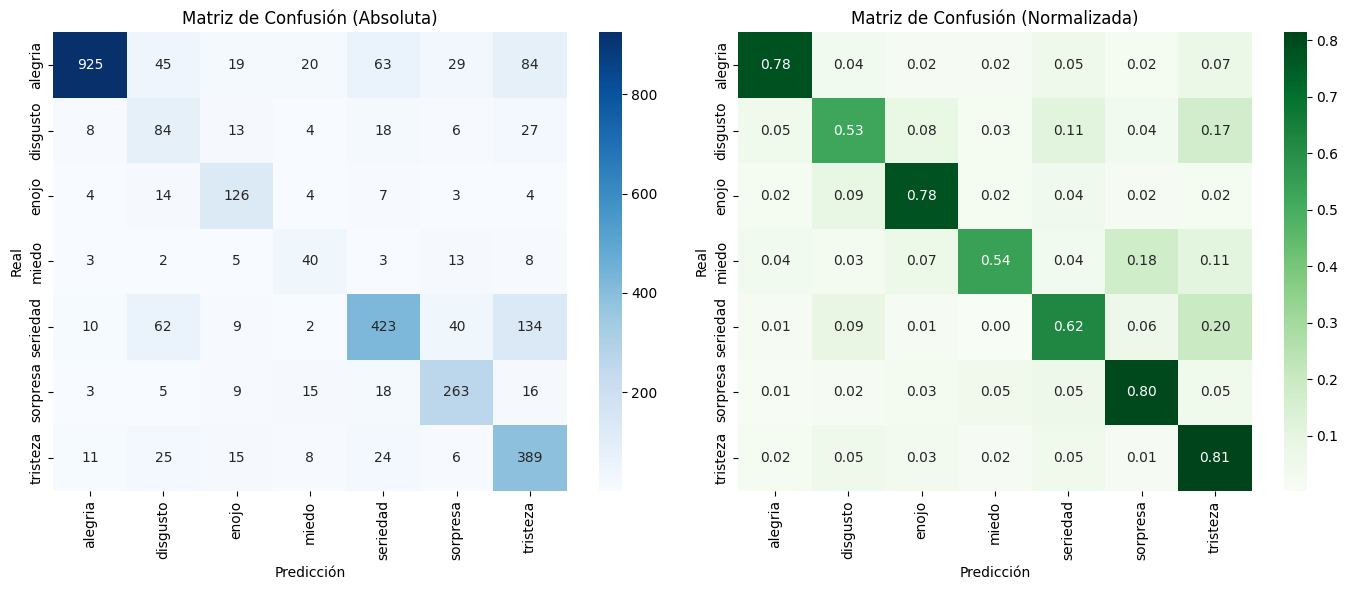

In [ ]:
evaluate_model(model, dataloader['test'], class_names=train_ds.classes)

## Conclusiones de evaluación

**Resumen global.** El modelo alcanza **Accuracy en test = 0.7334** y **F1 macro = 0.6568**, superando un umbral razonable (≥ 0.70). La brecha entre **F1 macro (0.657)** y el **weighted F1 (0.743)** pueden deberse al **desbalance de clases**: las mayoritarias pesan más en el promedio ponderado.

### Lectura de las curvas
- **Loss:** la pérdida de entrenamiento desciende de forma sostenida; la de validación baja rápido y luego **oscila** alrededor de ~1.0–1.2. No aparece sobreajuste severo.  
- **Accuracy:** el *train acc* sube hasta ~**0.92**, mientras el *val acc* se **estabiliza** entre **0.73–0.76** (picos ~0.755 hacia las épocas 46–50). **Early stopping** se activa en la **época 62** al estancarse la mejora. La brecha *train–val* es **moderada** y coherente con buena capacidad + regularización (Dropout 0.1, AdamW con *weight decay*, y *Weighted Random Sampler*).

### Por clase (según *classification report*)
- **Fuertes / más confiables**
  - **alegría:** prec. **0.960**, *recall* **0.781**, F1 **0.861**.  
  - **sorpresa:** *recall* **0.799**, F1 **0.763**.  
  - **tristeza:** *recall* **0.814**, F1 **0.682** (buena cobertura; algo de confusión con seriedad).
- **Intermedias**
  - **enojo:** *recall* **0.778**, F1 **0.704** (mejoría respecto a corridas previas).  
  - **seriedad:** *recall* **0.622**, F1 **0.684**; se confunde con tristeza.
- **Más débiles (minoritarias)**
  - **disgusto:** *recall* **0.525**, F1 **0.423**.  
  - **miedo:** *recall* **0.541**, F1 **0.479**.  
  El **bajo soporte** (p. ej., miedo con 74 imágenes) y la **ambigüedad visual** explican parte del rendimiento.

### Qué muestra la matriz de confusión
- Diagonal sólida en **alegría (~0.78)**, **sorpresa (~0.80)**, **tristeza (~0.81)** y **enojo (~0.78)**.  
- Confusiones frecuentes y esperables:
  - **seriedad ↔ tristeza** (neutro vs. afecto negativo leve).  
  - **miedo ↔ sorpresa/tristeza** (ojos/boca abiertos vs. valencia negativa).  
  - **disgusto** disperso hacia **seriedad/tristeza**, consistente con su menor representación y rasgos menos distintivos.

### Conclusión
El rendimiento (**Acc 0.733**, **F1 macro 0.657**) es consistente con la dificultad del dataset y su desbalance. El modelo generaliza bien sin sobreajuste pronunciado y los errores se concentran en emociones cercanas semánticamente o poco representadas.  
Con esta configuración final (RGB, 64–128–256, Dropout 0.1, AdamW + *weight decay*, *ReduceLROnPlateau*, y *Weighted Random Sampler*) se cumple el objetivo de la práctica. El principal margen de mejora está en disgusto y miedo (más datos específicos, *augmentations* dirigidos y/o pérdidas focalizadas).

- **Se probó explícitamente sin RGB (grayscale)**, recalculando **normalización** y reforzando la **fully-connected**, pero no se logró llegar a un modelo que pueda superar el accuracy de la corrida 22.
  **Resultado:** no superó al modelo en **RGB**; la mejor *val_acc* quedó en ~**0.618**, por debajo del **0.7334** de test logrado con la configuración **22.0** (*RGB + class_weights + WRS*).
- La **cabeza FC** más profunda (GAP → 256 → 128 → salida) **mejoró estabilidad** respecto a FC simples, pero **no** fue suficiente para sobrepasar el tope de la configuración en RGB.
- **Balanceo:** confirmar que **no se combinó** `class_weights` con **WRS** en el mismo run (*opción A*), para evitar duplicar el sesgo.

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 5 imágenes personales de cualquier relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación.

- Cada imagen debe representar una emoción distinta.

- Aplicar el mismo pre-procesamiento que se usó para el dataset durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

In [ ]:
class_names=train_ds.classes

In [ ]:
# Descarga pública desde carpeta de Drive
# !pip -q install gdown

import gdown, os
from pathlib import Path

FOLDER_ID = "1hvPvr2K65AiS-BUpr18xqZVj4zSOht2R"
DEST = Path("public_photos")
DEST.mkdir(exist_ok=True)

# Descarga todo el contenido de esa carpeta
gdown.download_folder(id=FOLDER_ID, output=str(DEST), quiet=False, use_cookies=False)

# Listar imágenes descargadas
EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
imagenes = sorted([p for p in DEST.rglob("*") if p.suffix.lower() in EXTS])
print(f"Se encontraron {len(imagenes)} imágenes en {DEST}")

Retrieving folder contents


Processing file 1sNZ57HAREFlfzBfP8IdpXOH2uR-cRAHv 01.png
Processing file 1_9smhHSqWGnPGUGfkF8Q7yxrQfsJWvvz 02.jpeg
Processing file 1ik3_Q1jexIGsNddFXXONoBL23XhCVOyG 03.jpeg
Processing file 1PGRMqG8FxDQZgT6HYiE_g7DEmjsnou9Y 04.png
Processing file 1TYJVCS3cETtX2fRAMSeweEcEI22L7r8C 05.jpeg
Processing file 1dsFibQQ3m_UPNqBGUygicTaV5dTq4xyN 06.jpg
Processing file 19HYew0-G_P9_xcLfWM6yqQkWUZf1o5Dm 07.jpg
Processing file 1SXKdA_ijBvvwFE5mgL8-FWLqREFqdp-s 08.jpeg


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1sNZ57HAREFlfzBfP8IdpXOH2uR-cRAHv
To: /content/public_photos/01.png
100%|██████████| 70.3k/70.3k [00:00<00:00, 85.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_9smhHSqWGnPGUGfkF8Q7yxrQfsJWvvz
To: /content/public_photos/02.jpeg
100%|██████████| 11.6k/11.6k [00:00<00:00, 22.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ik3_Q1jexIGsNddFXXONoBL23XhCVOyG
To: /content/public_photos/03.jpeg
100%|██████████| 95.1k/95.1k [00:00<00:00, 82.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PGRMqG8FxDQZgT6HYiE_g7DEmjsnou9Y
To: /content/public_photos/04.png
100%|██████████| 41.5k/41.5k [00:00<00:00, 46.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TYJVCS3cETtX2fRAMSeweEcEI22L7r8C
To: /content/public_photos/05.jpeg
100%|██████████| 43.5k/43.5k [00:00<00:00, 51.6MB/s]
Downloading...
From: https:

Se encontraron 8 imágenes en public_photos



Download completed


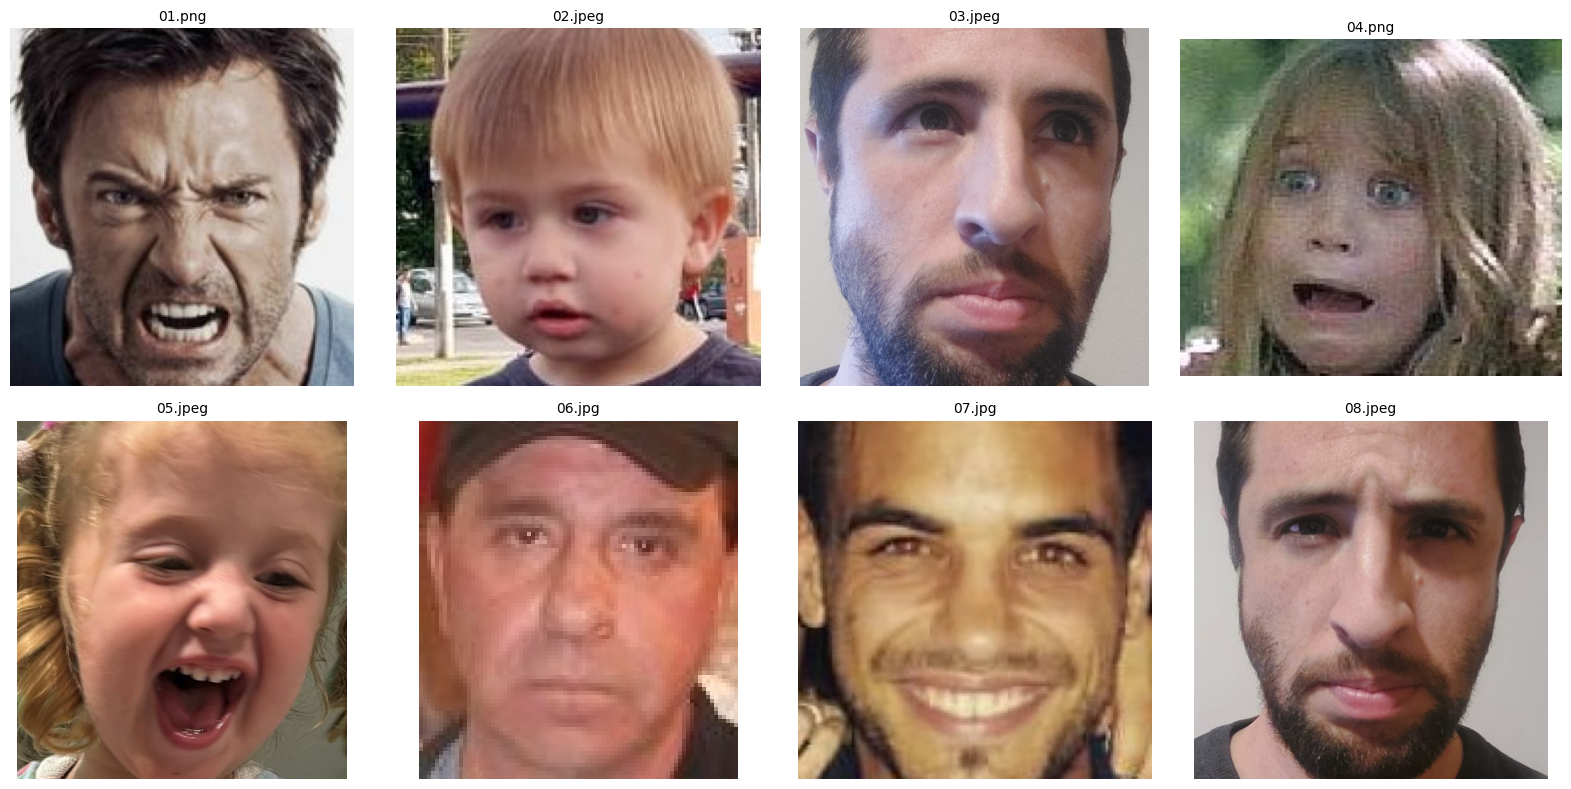

In [ ]:
from math import ceil

# Listado de imágenes (ordenadas)
# imagenes = [p for p in sorted(RUTA.iterdir()) if p.suffix.lower() in EXTS]
# print(f"Encontradas {len(imagenes)} imágenes en {RUTA}")

# Mostrar hasta 8 imágenes
N = min(len(imagenes), 8)
if N == 0:
    raise SystemExit("No se encontraron imágenes. Subí archivos a la carpeta indicada.")

# Grid dinámico: 1 o 2 filas, hasta 4 columnas
cols = min(4, N)
rows = ceil(N / cols)

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
axs = axs.ravel()  # array 1D de AxesSubplot

for i in range(N):
    img = Image.open(imagenes[i]).convert("RGB")
    axs[i].imshow(img)
    axs[i].set_title(imagenes[i].name, fontsize=10)
    axs[i].axis('off')

# Ocultar ejes sobrantes si hay
for j in range(N, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

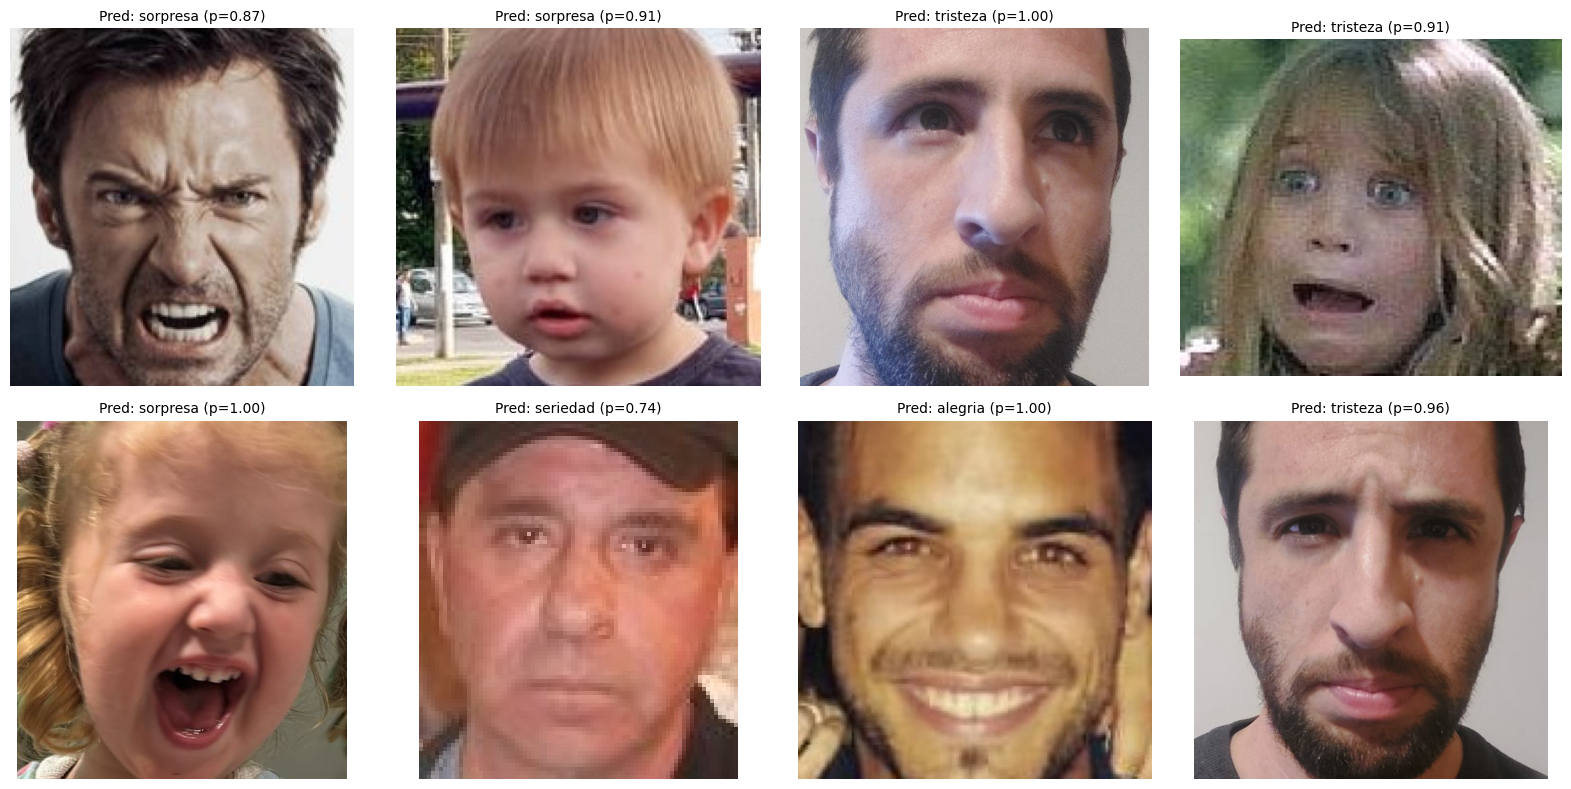

In [ ]:
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from math import ceil

# --- Mismo transform de TEST que usaste en el entrenamiento ---
# (Si ya existe test_transform, se reutiliza)
try:
    test_transform
except NameError:
    test_transform = transforms.Compose([
        transforms.Resize((100, 100)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])

# --- Nombres de clases ---
try:
    class_names = train_ds.classes
except NameError:
    try:
        class_names = dataloader['train'].dataset.classes
    except Exception:
        class_names = [str(i) for i in range(7)]  # fallback

# --- Device coherente con el entorno/modelo ---
device = (device if 'device' in globals()
          else (next(model.parameters()).device if 'model' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')))

# --- Chequeo de imágenes (usa la lista 'imagenes' creada antes) ---
if 'imagenes' not in globals() or len(imagenes) == 0:
    raise SystemExit("No hay imágenes cargadas. Ejecutá la celda de listado/visualización primero.")

# Grid dinámico: hasta 8 imágenes, 1–2 filas y hasta 4 columnas
N = min(len(imagenes), 8)
cols = min(4, N)
rows = ceil(N / cols)

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
axs = axs.ravel()

# --- Predicción y visualización simple ---
model.eval()
with torch.no_grad():
    for i in range(N):
        img_pil = Image.open(imagenes[i]).convert("RGB")
        x = test_transform(img_pil).unsqueeze(0).to(device)    # [1, 3, 100, 100]
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)

        axs[i].imshow(img_pil)
        axs[i].set_title(f"Pred: {pred_name} (p={probs[pred_idx]:.2f})", fontsize=10)
        axs[i].axis('off')

# Ocultar ejes sobrantes si hay
for j in range(N, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

### 4. Prueba de Imágenes Nuevas — Resultados y conclusiones

**Metodología.** Se evaluaron **8 imágenes propias/externas** nunca vistas por el modelo.  
Se aplicó **el mismo preprocesamiento de test** que en el entrenamiento: `Resize(100×100) → ToTensor → Normalize([0.5]*3, [0.5]*3)`.  
No se utilizaron *augmentations* ni detección/recorte de rostro (eso se analiza en el **Punto 5**).

> Nota práctica: para que el modelo rinda bien, conviene usar imágenes **cuadradas**, con la **cara bien centrada**, **frontal** (no de perfil) y sin anteojos. Inclinaciones pronunciadas y mucho fondo dificultan la predicción.

#### Resumen de inferencias (mini–set de 8 imágenes)

| Img | Origen | Emoción “esperada” (visual) | Predicción (p) | ¿Correcta? | Comentario |
| --- | --- | --- | --- | :--: | --- |
| 01.png | Stock/actor | enojo | **sorpresa** (0.87) | **No** | Boca muy abierta y dientes visibles disparan “sorpresa”. |
| 02.jpeg | Personal (niño) | sorpresa / tristeza | **sorpresa** (0.91) | **Sí** | Rasgos claros de sorpresa (ojos/boca). |
| 03.jpeg | Personal (autor) | tristeza / (disgusto/enojo) | **tristeza** (1.00) | **Sí\*** | Caso ambiguo; ceño/gesto podrían leerse como disgusto/enojo. |
| 04.png | Stock/actor | miedo / (sorpresa) | **tristeza** (0.91) | **No** | Ojos muy abiertos sugieren miedo; el modelo lo aproxima a tristeza. |
| 05.jpeg | Personal (niña) | sorpresa | **sorpresa** (1.00) | **Sí** | Señales faciales muy marcadas. |
| 06.jpg | Personal (amigo) | seriedad | **seriedad** (0.74) | **Sí** | Expresión neutra/seria, buena iluminación, pero menor resolución. |
| 07.jpg | Personal (amigo) | alegría | **alegría** (1.00) | **Sí** | Sonrisa franca; alta confianza. |
| 08.jpeg | Personal (autor) | tristeza | **tristeza** (0.96) | **Sí** | Ceño y comisuras hacia abajo bien capturados. |

**Balance:** 6/8 aciertos (**75%**) en este conjunto pequeño y variado.

#### Observaciones
- Los **aciertos** muestran **confianzas altas** (p ≥ 0.74), especialmente en **alegría** y **sorpresa**, coherente con lo observado en el *classification report* del set de test.
- Los **errores** (01 y 04) ocurren en **emociones cercanas** o **ambiguas** sin contexto (enojo ↔ sorpresa, miedo ↔ tristeza/sorpresa).  
- La **composición** de la foto importa: rostros **centrados y frontales** ayudan significativamente.

#### Conclusión preliminar
En imágenes nuevas y no vistas, el modelo **generaliza bien**: identifica correctamente 6/8 casos con **alta confianza** en las clases de rasgos más distintivos (alegría/sorpresa) y presenta dudas en **emociones ambiguas** (miedo/enojo vs. sorpresa/tristeza).  
Los resultados son **aceptables** y coherentes con lo observado en test. En los puntos siguientes (Punto 5) se evalúa **detectar/recortar rostro** antes de inferir, lo que ayuda a reducir el ruido de fondo y mejorar los casos difíciles (como 01 y 04).

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 5 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase
  - La clase ganadora inferida por el modelo

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

NOTA: Pueden adaptar el código según crean conveniente para obtener mejores resultados.

#### Se adapta el código buscando obtener mejores resultados

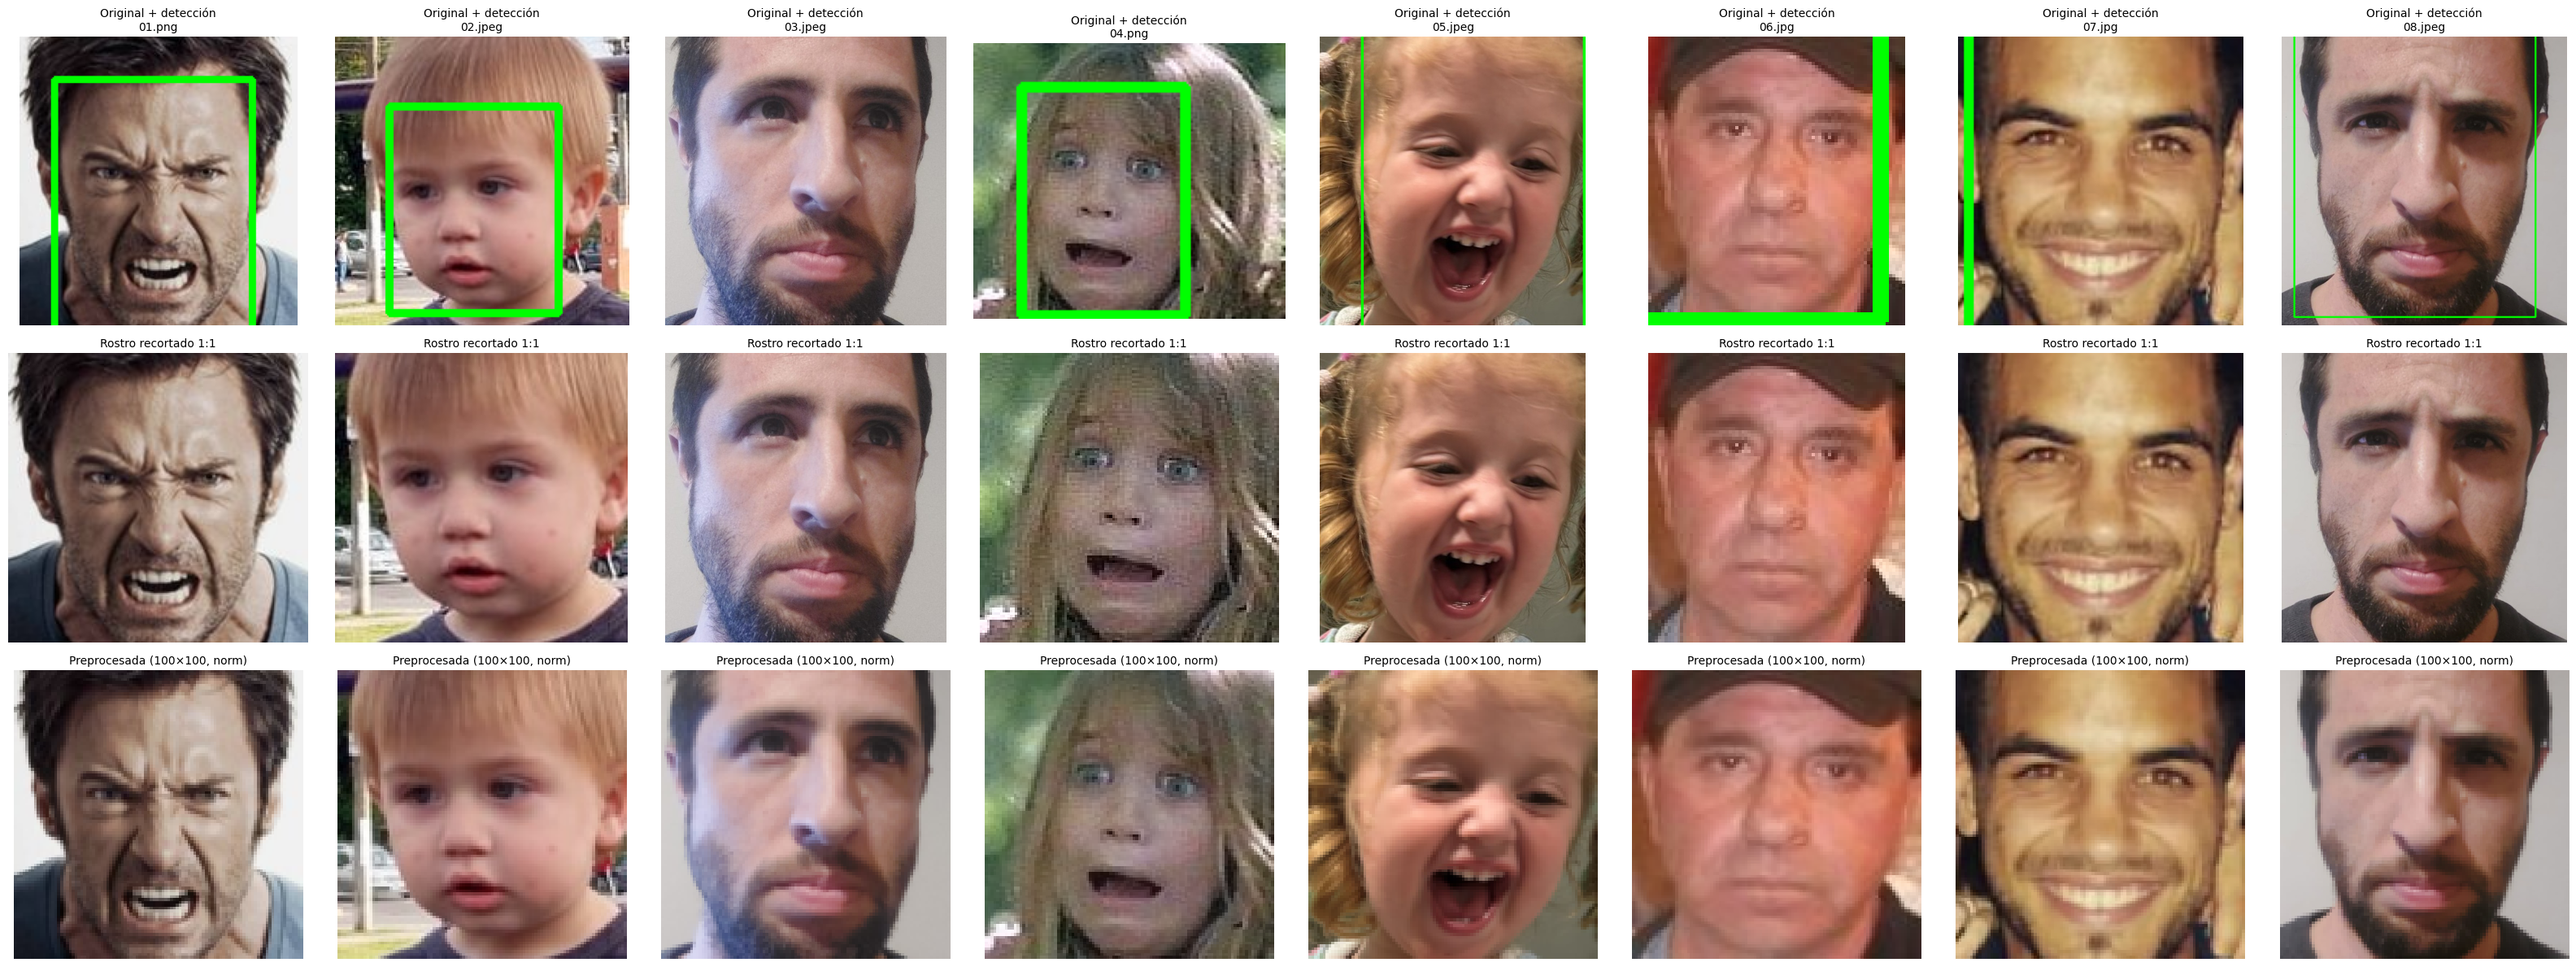

In [ ]:
# --- Punto 5: Detección de rostro y recorte 1:1, luego preprocesamiento e inferencia ---

import cv2
import numpy as np
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from math import ceil
import pandas as pd

# 1) Transform de test (mismo que en entrenamiento)
try:
    test_transform
except NameError:
    test_transform = transforms.Compose([
        transforms.Resize((100, 100)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])

# Para visualizar la "preprocesada" (des-normalizar a [0,1])
def denorm(t, mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]):
    mean = torch.tensor(mean).view(-1,1,1)
    std  = torch.tensor(std).view(-1,1,1)
    x = t*std + mean
    return torch.clamp(x, 0, 1)

# 2) Nombres de clases
try:
    class_names = class_names  # ya definido
except NameError:
    try:
        class_names = train_ds.classes
    except Exception:
        class_names = [str(i) for i in range(7)]

# 3) Device
device = (device if 'device' in globals()
          else (next(model.parameters()).device if 'model' in globals() else ('cuda' if torch.cuda.is_available() else 'cpu')))

# === Detector principal: MTCNN ===
try:
    from facenet_pytorch import MTCNN
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "facenet-pytorch"], check=True)
    from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    keep_all=True,
    thresholds=[0.7, 0.75, 0.8],      # ← más estricto (menos falsos positivos)
    min_face_size=28,                 # se puede subir a 28–40 si hay caras pequeñas ruidosas
    device=(device if str(device) != "cpu" else None)
)


# 4) Lista de imágenes (del punto 4)
if 'imagenes' not in globals() or len(imagenes) == 0:
    raise SystemExit("No hay imágenes cargadas. Ejecutá antes el bloque del Punto 4 para listar 'imagenes'.")

# 5) Detector de rostros (Haar Cascade)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# --- Cascades más robustos ---
frontal_default = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
frontal_alt2    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml")
frontal_tree    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt_tree.xml")
profile_face    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_profileface.xml")

def _run_cascade(gray, cascade,
                 scale_factors=(1.05, 1.10, 1.20),
                 min_neighbors=(3, 5, 6),
                 min_size_fracs=(0.05, 0.08, 0.12)):
    """Barre combinación de parámetros y concatena detecciones."""
    H, W = gray.shape[:2]
    faces = []
    for sf in scale_factors:
        for mn in min_neighbors:
            for frac in min_size_fracs:
                ms = (max(1, int(W*frac)), max(1, int(H*frac)))
                found = cascade.detectMultiScale(gray, scaleFactor=sf, minNeighbors=mn, minSize=ms)
                if len(found):
                    faces.extend(found)
    return faces

def detect_and_crop_square_haar(pil_img, pad_ratio=0.28):
    """
    Devuelve (cropped_pil, boxed_rgb). Si no detecta, cropped_pil=None.
    """
    bgr  = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    H, W = bgr.shape[:2]

    # 1) Grises + CLAHE (mejora contraste en pieles suaves / fotos de niños / blur)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # 2) Intentos con cascades frontales
    faces = []
    for cas in (frontal_default, frontal_alt2, frontal_tree):
        faces += _run_cascade(gray, cas)

    # 3) Si no hay nada, probar perfil (izq/der: espejamos y remapeamos)
    if not len(faces):
        for flip in (False, True):
            g = cv2.flip(gray, 1) if flip else gray
            found = _run_cascade(g, profile_face,
                                 scale_factors=(1.05, 1.10, 1.20),
                                 min_neighbors=(3, 4, 5),
                                 min_size_fracs=(0.05, 0.08, 0.12))
            if len(found):
                if flip:
                    # mapear coordenadas desde imagen espejada
                    mapped = [(W - x - w, y, w, h) for (x,y,w,h) in found]
                    faces.extend(mapped)
                else:
                    faces.extend(found)

    # 4) Último recurso: reescalar y volver a intentar (ayuda con caras muy pequeñas)
    if not len(faces):
        scale = 1.6
        gray2 = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
        tmp = []
        for cas in (frontal_default, frontal_alt2):
            tmp += _run_cascade(gray2, cas,
                                scale_factors=(1.05, 1.10),
                                min_neighbors=(3, 4),
                                min_size_fracs=(0.04, 0.06))
        if len(tmp):
            faces = [(int(x/scale), int(y/scale), int(w/scale), int(h/scale)) for (x,y,w,h) in tmp]

    # Dibujar cajas para visualización
    boxed = bgr.copy()
    for (x,y,w,h) in faces:
        cv2.rectangle(boxed, (x,y), (x+w, y+h), (0,255,0), 2)
    boxed_rgb = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)

    if not len(faces):
        return None, boxed_rgb

    # 5) Elegir el rostro más grande
    x,y,w,h = max(faces, key=lambda r: r[2]*r[3])

    # 6) Recorte 1:1 con padding
    cx, cy = x + w//2, y + h//2
    side = int(max(w, h) * (1 + pad_ratio))
    x1 = max(0, cx - side//2)
    y1 = max(0, cy - side//2)
    x2 = min(W, cx + side//2)
    y2 = min(H, cy + side//2)

    crop = bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None, boxed_rgb

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    return Image.fromarray(crop_rgb), boxed_rgb

def detect_and_crop_square_mtcnn(pil_img, pad_ratio=0.22):
    """
    Detecta con MTCNN y devuelve (crop PIL o None, imagen con bbox RGB).
    Aplica un umbral de probabilidad para filtrar detecciones débiles.
    """
    img = pil_img.convert("RGB")
    W, H = img.size

    boxes, probs = mtcnn.detect(img)  # boxes: (N, 4), probs: (N,)
    boxed = np.array(img).copy()

    # Si no hay detecciones, devolver None
    if boxes is None or len(boxes) == 0:
        return None, boxed

    # --- Filtro extra por probabilidad ---
    THRESH = 0.85
    probs = np.asarray(probs)              # asegurar ndarray
    mask = probs >= THRESH                 # filtro
    boxes = boxes[mask]
    probs = probs[mask]
    if boxes is None or len(boxes) == 0:
        return None, boxed
    # -------------------------------------

    # Elegir la caja más grande
    areas = [(x2 - x1) * (y2 - y1) for (x1, y1, x2, y2) in boxes]
    i = int(np.argmax(areas))
    x1, y1, x2, y2 = boxes[i]
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # Dibujar bbox
    cv2.rectangle(boxed, (x1, y1), (x2, y2), (0, 255, 0), 3)

    # Expandir a 1:1 con padding
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    side  = max(x2 - x1, y2 - y1) * (1 + pad_ratio)
    xn1 = max(0, int(cx - side / 2)); yn1 = max(0, int(cy - side / 2))
    xn2 = min(W, int(cx + side / 2)); yn2 = min(H, int(cy + side / 2))

    crop = img.crop((xn1, yn1, xn2, yn2))
    return crop, boxed


def detect_and_crop_square(pil_img, pad_ratio=0.22):
    """
    API final que usa primero MTCNN y si falla, cae a Haar.
    """
    crop, boxed = detect_and_crop_square_mtcnn(pil_img, pad_ratio=pad_ratio)
    if crop is not None:
        return crop, boxed
    return detect_and_crop_square_haar(pil_img, pad_ratio=pad_ratio)



# 6) Selección de imágenes
N = max(5, min(len(imagenes), 8))
subset = imagenes[:N]

# 7) Visualización: Original con caja | Rostro recortado | Preprocesada
cols = N
rows = 3
fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)

for i, path in enumerate(subset):
    pil_img = Image.open(path).convert("RGB")
    cropped_pil, boxed_rgb = detect_and_crop_square(pil_img, pad_ratio=0.15)

    # original con caja
    axs[0, i].imshow(boxed_rgb)
    axs[0, i].set_title(f"Original + detección\n{path.name}", fontsize=10)
    axs[0, i].axis('off')

    # recorte (o fallback)
    if cropped_pil is None:
        axs[1, i].text(0.5, 0.5, "No se detectó rostro", ha='center', va='center')
        axs[1, i].axis('off')
        x_for_transform = pil_img  # fallback: usar original
    else:
        axs[1, i].imshow(cropped_pil)
        axs[1, i].set_title("Rostro recortado 1:1", fontsize=10)
        axs[1, i].axis('off')
        x_for_transform = cropped_pil

    # preprocesada (mismo pipeline de test)
    x_tensor = test_transform(x_for_transform)  # C,H,W normalizado
    viz = denorm(x_tensor)  # para ver bien
    axs[2, i].imshow(transforms.ToPILImage()(viz))
    axs[2, i].set_title("Preprocesada (100×100, norm)", fontsize=10)
    axs[2, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def predict_pil(pil_img, transform, device, class_names):
    x = transform(pil_img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
    return probs, pred_idx, pred_name

records_orig, records_crop, summary = [], [], []

model.eval()
for path in subset:
    pil_img = Image.open(path).convert("RGB")
    cropped_pil, _ = detect_and_crop_square(pil_img, pad_ratio=0.15)

    # Predicción con imagen original
    probs_o, idx_o, name_o = predict_pil(pil_img, test_transform, device, class_names)
    row_o = {"imagen": path.name, "pred_original": name_o, "p_original": float(probs_o[idx_o])}
    for j, cname in enumerate(class_names):
        row_o[f"p({cname})"] = float(probs_o[j])
    records_orig.append(row_o)

    # Predicción con recorte (o fallback)
    crop_input = cropped_pil if cropped_pil is not None else pil_img
    probs_c, idx_c, name_c = predict_pil(crop_input, test_transform, device, class_names)
    row_c = {"imagen": path.name, "pred_crop": name_c, "p_crop": float(probs_c[idx_c])}
    for j, cname in enumerate(class_names):
        row_c[f"p({cname})"] = float(probs_c[j])
    records_crop.append(row_c)

    summary.append({
        "imagen": path.name,
        "pred_original": name_o, "p_original": float(probs_o[idx_o]),
        "pred_crop": name_c, "p_crop": float(probs_c[idx_c]),
        "changed": name_o != name_c
    })

df_scores_original = pd.DataFrame.from_records(records_orig)
df_scores_cropped  = pd.DataFrame.from_records(records_crop)
df_summary         = pd.DataFrame.from_records(summary)

print("=== Resumen por imagen (original vs recortada) ===")
display(df_summary)

print("\n=== Scores por clase (original) ===")
display(df_scores_original)

print("\n=== Scores por clase (recortada) ===")
display(df_scores_cropped)

# (Opcional) Guardar CSVs
# df_summary.to_csv("resumen_p5.csv", index=False)
# df_scores_original.to_csv("scores_original_p5.csv", index=False)
# df_scores_cropped.to_csv("scores_crop_p5.csv", index=False)

=== Resumen por imagen (original vs recortada) ===


,imagen,pred_original,p_original,pred_crop,p_crop,changed
0,01.png,sorpresa,0.873251,enojo,0.999657,True
1,02.jpeg,sorpresa,0.912903,tristeza,0.976718,True
2,03.jpeg,tristeza,0.995587,tristeza,0.995587,False
3,04.png,tristeza,0.907220,sorpresa,0.647940,True
4,05.jpeg,sorpresa,0.999967,sorpresa,0.999967,False
5,06.jpg,seriedad,0.735854,seriedad,0.735854,False
6,07.jpg,alegria,0.999605,alegria,0.999605,False
7,08.jpeg,tristeza,0.963805,tristeza,0.963805,False



=== Scores por clase (original) ===


,imagen,pred_original,p_original,p(alegria),p(disgusto),p(enojo),p(miedo),p(seriedad),p(sorpresa),p(tristeza)
0,01.png,sorpresa,0.873251,3.257345e-04,3.424051e-11,1.258538e-01,7.011255e-10,5.511865e-06,8.732514e-01,0.000563
1,02.jpeg,sorpresa,0.912903,4.087413e-05,2.683622e-05,1.714227e-05,1.588925e-07,8.333925e-02,9.129029e-01,0.003673
2,03.jpeg,tristeza,0.995587,1.209875e-05,1.477821e-03,8.110746e-06,7.049884e-10,2.908419e-03,7.037592e-06,0.995587
3,04.png,tristeza,0.907220,4.782645e-04,2.062085e-06,2.084261e-05,1.022249e-02,1.329975e-02,6.875645e-02,0.907220
4,05.jpeg,sorpresa,0.999967,3.000755e-09,2.669020e-08,1.980853e-09,2.121874e-07,8.926214e-08,9.999667e-01,0.000033
5,06.jpg,seriedad,0.735854,5.104830e-03,7.982791e-03,5.387727e-04,3.732448e-04,7.358537e-01,2.346615e-01,0.015485
6,07.jpg,alegria,0.999605,9.996052e-01,1.689330e-07,1.495531e-07,5.458035e-10,8.301576e-06,1.253712e-10,0.000386
7,08.jpeg,tristeza,0.963805,4.346407e-08,3.177641e-06,8.163437e-06,4.467584e-04,3.573303e-02,3.909005e-06,0.963805



=== Scores por clase (recortada) ===


,imagen,pred_crop,p_crop,p(alegria),p(disgusto),p(enojo),p(miedo),p(seriedad),p(sorpresa),p(tristeza)
0,01.png,enojo,0.999657,5.268866e-06,2.765489e-09,9.996573e-01,5.969137e-08,3.388233e-06,3.290359e-04,0.000005
1,02.jpeg,tristeza,0.976718,8.793157e-06,8.547784e-07,1.116111e-07,5.881862e-11,9.104086e-03,1.416851e-02,0.976718
2,03.jpeg,tristeza,0.995587,1.209875e-05,1.477821e-03,8.110746e-06,7.049884e-10,2.908419e-03,7.037592e-06,0.995587
3,04.png,sorpresa,0.647940,1.060134e-09,3.903345e-09,1.039423e-07,9.940894e-07,5.238086e-06,6.479401e-01,0.352054
4,05.jpeg,sorpresa,0.999967,3.000755e-09,2.669020e-08,1.980853e-09,2.121874e-07,8.926214e-08,9.999667e-01,0.000033
5,06.jpg,seriedad,0.735854,5.104830e-03,7.982791e-03,5.387727e-04,3.732448e-04,7.358537e-01,2.346615e-01,0.015485
6,07.jpg,alegria,0.999605,9.996052e-01,1.689330e-07,1.495531e-07,5.458035e-10,8.301576e-06,1.253712e-10,0.000386
7,08.jpeg,tristeza,0.963805,4.346407e-08,3.177641e-06,8.163437e-06,4.467584e-04,3.573303e-02,3.909005e-06,0.963805


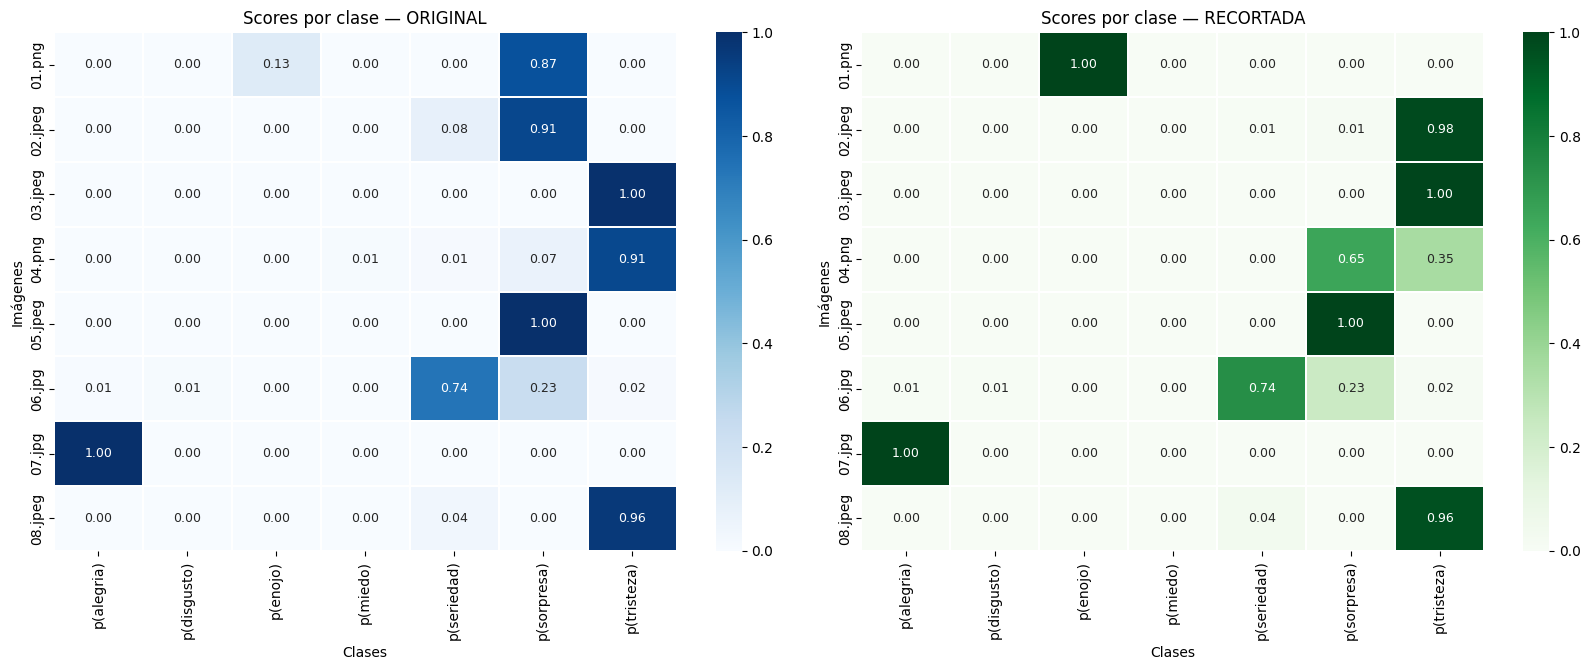

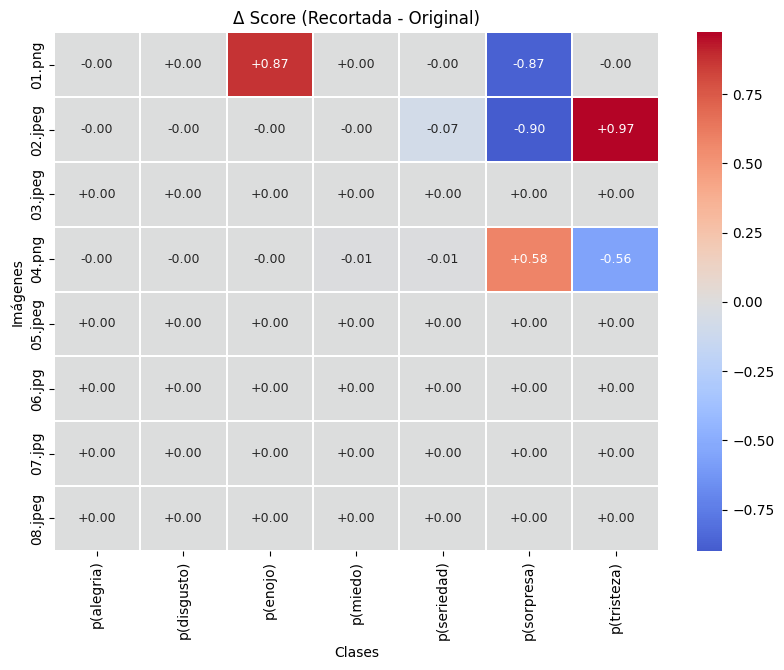

In [ ]:
# Heatmaps de scores por clase (ORIGINAL vs RECORTADA) con valores en cada celda
# Usa df_scores_original y df_scores_cropped ya creados

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1) Determinar el orden de columnas de probabilidad (clases)
if 'class_names' in globals() and isinstance(class_names, (list, tuple)):
    prob_cols = [f"p({c})" for c in class_names if f"p({c})" in df_scores_original.columns]
else:
    prob_cols = [c for c in df_scores_original.columns if c.startswith("p(") and c.endswith(")")]
    prob_cols = [c for c in prob_cols if c in df_scores_cropped.columns]

# 2) Construir matrices con índice = nombre de imagen (acortado) y columnas = clases
def _short_name(s, maxlen=32):
    return s[:maxlen] + ("…" if len(s) > maxlen else "")

df_orig_heat = df_scores_original.set_index("imagen")[prob_cols].copy()
df_orig_heat.index = df_orig_heat.index.map(_short_name)

df_crop_heat = df_scores_cropped.set_index("imagen")[prob_cols].copy()
df_crop_heat.index = df_crop_heat.index.map(_short_name)

# 3) (Opcional) limitar a 8 imágenes
N = min(8, len(df_orig_heat))
df_orig_heat = df_orig_heat.iloc[:N]
df_crop_heat = df_crop_heat.iloc[:N]

# 4) Graficar heatmaps lado a lado (con anotaciones)
C = len(prob_cols)
fig_w = 2 + 0.9 * C
fig_h = 2 + 0.6 * N

fig, axes = plt.subplots(1, 2, figsize=(fig_w*2, fig_h), squeeze=False)
ax1, ax2 = axes.ravel()

sns.heatmap(
    df_orig_heat, ax=ax1, cmap="Blues", vmin=0, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size":9}, cbar=True, linewidths=0.3, linecolor="white"
)
ax1.set_title("Scores por clase — ORIGINAL", fontsize=12)
ax1.set_xlabel("Clases")
ax1.set_ylabel("Imágenes")

sns.heatmap(
    df_crop_heat, ax=ax2, cmap="Greens", vmin=0, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size":9}, cbar=True, linewidths=0.3, linecolor="white"
)
ax2.set_title("Scores por clase — RECORTADA", fontsize=12)
ax2.set_xlabel("Clases")
ax2.set_ylabel("Imágenes")

plt.tight_layout()
plt.show()

# 5) Heatmap de diferencias: RECORTADA - ORIGINAL (con anotaciones)
df_delta = (df_crop_heat - df_orig_heat).reindex(columns=prob_cols)

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))
sns.heatmap(
    df_delta, ax=ax, cmap="coolwarm", center=0,
    annot=True, fmt="+.2f", annot_kws={"size":9}, linewidths=0.3, linecolor="white"
)
ax.set_title("Δ Score (Recortada - Original)", fontsize=12)
ax.set_xlabel("Clases")
ax.set_ylabel("Imágenes")
plt.tight_layout()
plt.show()

### 5) Prueba de Imágenes Nuevas con **pre-procesamiento adicional** (detección y recorte de rostro)

#### Qué cambié respecto del código base
- **Detector principal:** pasé a **MTCNN** (de `facenet_pytorch`) y dejé **Haar cascades** como *fallback*.
- **Filtros de calidad de detección:**
  - `thresholds=[0.70, 0.75, 0.80]` en MTCNN (más estricto → menos falsos positivos).
  - **Filtro extra** por probabilidad: `probs >= 0.85`.
  - `min_face_size=28` (evita caras muy pequeñas/ruidosas).
- **Fallback más robusto (Haar):**
  - **CLAHE** en escala de grises (mejora contraste).
  - Varias cascadas frontales (`default/alt2/alt_tree`) + **perfil** (izq/der con *flip*).
  - Reintento **reescalando** (pirámide) cuando no hay detección.
- **Recorte 1:1 con padding** (≈15–22%) y **mismo pipeline** de test: `Resize(100×100) → ToTensor → Normalize`.

---

#### Resultados vs. Punto 4
**Resumen:** el recorte automático **cambió 3/8** predicciones; en **2/3** casos el cambio fue una **mejora clara** (01 y 04).

| imagen | pred_original | p_original | pred_crop | p_crop | changed |
|:------:|:--------------|-----------:|:----------|-------:|:------:|
| 01.png | sorpresa      | 0.8733     | **enojo**     | **0.9997** | Sí |
| 02.jpeg| sorpresa      | 0.9129     | **tristeza**  | **0.9767** | Sí |
| 03.jpeg| tristeza      | 0.9956     | tristeza  | 0.9956 | No |
| 04.png | tristeza      | 0.9072     | **sorpresa**  | **0.6479** | Sí |
| 05.jpeg| sorpresa      | 1.0000     | sorpresa  | 1.0000 | No |
| 06.jpg | seriedad      | 0.7359     | seriedad  | 0.7359 | No |
| 07.jpg | alegria       | 0.9996     | alegria   | 0.9996 | No |
| 08.jpeg| tristeza      | 0.9638     | tristeza  | 0.9638 | No |

**Lectura cualitativa (apoyado por los heatmaps):**
- **01** (enojo): el recorte llevó la probabilidad de *enojo* de ~0.13 a **~1.00** y **bajó** *sorpresa* ~0.87 → ~0.00 (Δ≈+0.87/−0.87). El fondo y encuadre original confundían.
- **04** (niña): cambió de *tristeza* (0.91) a **sorpresa** (0.65). El recorte centró ojos/boca abiertos y mejoró la señal (Δ +0.58 en *sorpresa*, −0.56 en *tristeza*).
- **02**: pasó de *sorpresa* a **tristeza** con alta confianza (0.98). La expresión es ambigua y compatible con **“decepción”** (mezcla sorpresa–tristeza), por lo que el cambio es **razonable**. Ese día momentos antes él se había caído y había llorado, lo que puede explicar esta expresión tiempo después.
- En las imágenes **05/06/07/08** no cambió la clase; las caras ya estaban centradas y el recorte mantuvo o consolidó la distribución de *scores*.

---

#### Conclusiones finales del Punto 5
- Incorporar **detección + recorte** (MTCNN→Haar) **mejora la precisión y la confianza** cuando hay **fondo dominante**, encuadre laxo o ligeras **inclinaciones**: se corrigieron **2** casos relevantes (01 y 04) y se obtuvo un cambio plausible en otro (02).
- El **preprocesamiento consistente** (recorte 1:1 + `Resize 100×100` + normalización) ayuda a **alinear** las imágenes nuevas con la distribución vista en entrenamiento.
- **Limitaciones**:
  - MTCNN puede ignorar caras **muy pequeñas**/ocultas si el umbral es alto; por eso se dejó **Haar** como respaldo.
  - **Anteojos, perfil pronunciado o blur** siguen siendo desafiantes; la **alineación por *landmarks*** de MTCNN sería un siguiente paso natural.

> En síntesis, el pipeline de detección + recorte **mejoró la interpretación** del modelo en imágenes reales, especialmente cuando el contexto visual podía sesgar la predicción. Con alineación por *landmarks* y *augmentations* específicas es razonable esperar mejoras adicionales.

## Conclusión general

A lo largo del trabajo se construyó un **pipeline completo y consistente** (normalización por estadísticas del *train*, *data augmentation* moderado, balanceo con `class_weights` y `WeightedRandomSampler`) y se iteró de forma sistemática sobre **22 configuraciones** de arquitectura y entrenamiento hasta llegar a un modelo CNN **64–128–256** con **Dropout 0.1**, **AdamW** (*weight decay* = 1e-4) y **ReduceLROnPlateau**.

El modelo final alcanzó en test **Accuracy = 0.7334** y **F1 macro = 0.6568**, resultados coherentes con el desbalance y la dificultad intrínseca del dataset: rinde muy bien en clases con rasgos faciales más distintivos (*alegría, sorpresa, tristeza*) y muestra mayor confusión en clases ambiguas o minoritarias (*disgusto, miedo*).

Las pruebas con imágenes nuevas confirmaron la capacidad de generalización y evidenciaron la importancia del preprocesamiento: al incorporar detección y recorte de rostro (MTCNN → Haar como respaldo) se corrigieron predicciones sensibles al fondo/encuadre y aumentó la confianza de la clase correcta en varios casos.

Finalmente:

- El sistema final mantiene **buen rendimiento** en un dataset **desbalanceado**, con **test_acc = 0.7334** y **F1 macro ≈ 0.657**, y logra **predicciones robustas** en clases con rasgos más distintivos.
- El **color (RGB)**, aunque no es esencial para codificar la emoción, parece **ayudar** a este dataset concreto (posiblemente por matices de piel/iluminación/fondo correlacionados con la etiqueta), superando a la variante **grayscale**.
- Las **mejoras de capacidad en la FC** y el **balanceo cuidadoso** aportaron estabilidad, pero la **mejor relación sesgo-varianza** se alcanzó con la **configuración 22.0**.
- **Líneas futuras:** (i) **Focal Loss** o **class-balanced loss**, (ii) *mixup/cutmix* y **augmentaciones fotométricas** controladas, (iii) regularización con **label smoothing**, (iv) **validación estratificada k-fold** para estimar varianza, y (v) exploración de **backbones preentrenados** livianos (p.ej. MobileNetV3) manteniendo la cabeza FC reforzada.

**En síntesis:** se logró alcanzar un sistema estable, bien justificado y reproducible. El principal margen de mejora pasa por seguir trabajando sobre un modelo con un solo canal con **grayscale** y mejorar la **fully-connected** que no se pudo mejorar en este caso.